In [1]:
# I install the libraries needed for this project.
# I avoid PyTorch Geometric because the graph layers are implemented manually in this notebook.

!pip -q install mne tqdm scikit-learn

print("Package installation finished.")
print("Warnings from Colab are acceptable unless the next import cell fails.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 49.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Package installation finished.
Warnings from Colab are acceptable unless the next import cell fails.


In [2]:
import os
import re
import json
import math
import time
import random
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from IPython.display import display

import mne
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Imports completed.")
print("Device:", DEVICE)
print("Seed:", SEED)

Imports completed.
Device: cpu
Seed: 42


In [3]:
# Google Drive is off by default so the professor can run everything without permission prompts.

USE_GOOGLE_DRIVE = False
FORCE_REPROCESS = False

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/Final_EEG_Graph_Seizure_Project")
else:
    PROJECT_DIR = Path("/content/Final_EEG_Graph_Seizure_Project")

RAW_DIR = PROJECT_DIR / "raw_chbmit"
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

for folder in [RAW_DIR, PROCESSED_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PHYSIONET_BASE_URL = "https://physionet.org/files/chbmit/1.0.0"

# These patients were selected because the previous experiments ran successfully with them.
PATIENT_IDS = ["chb01", "chb02", "chb03", "chb05", "chb06", "chb07", "chb08", "chb10"]

# Two seizure EDF files per patient keeps the notebook runnable in Colab.
MAX_SEIZURE_FILES_PER_PATIENT = 2

TARGET_SAMPLING_RATE = 128

WINDOW_SECONDS = 4
STRIDE_SECONDS = 2

NEGATIVE_RATIO = 3
MIN_NEGATIVE_WINDOWS_PER_FILE = 40

DESIRED_CHANNELS = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1",
    "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
    "FP2-F4", "F4-C4", "C4-P4", "P4-O2",
    "FP2-F8", "F8-T8", "T8-P8", "P8-O2",
    "FZ-CZ", "CZ-PZ"
]

N_CHANNELS = len(DESIRED_CHANNELS)
TOP_K_EDGES = 5

BATCH_SIZE = 64
MAX_EPOCHS = 45
PATIENCE = 9
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

CALIBRATION_WINDOWS_PER_PATIENT = 40

DPC_ALPHA_VALUES = [0.25, 0.50, 0.75, 1.00, 1.50, 2.00]
THRESHOLD_GRID = np.linspace(0.10, 0.90, 81)
FALSE_ALARM_PENALTY = 0.20

ENSEMBLE_RANDOM_SEARCHES = 250
BOOTSTRAP_ROUNDS = 1000
ROBUSTNESS_SPLIT_SEEDS = [13, 42, 77]

config_df = pd.DataFrame({
    "setting": [
        "project directory",
        "patients",
        "max seizure files per patient",
        "sampling rate",
        "window seconds",
        "stride seconds",
        "graph nodes",
        "top k edges",
        "DPC alpha values",
        "bootstrap rounds",
        "robustness split seeds",
        "Google Drive",
        "force reprocess"
    ],
    "value": [
        str(PROJECT_DIR),
        ", ".join(PATIENT_IDS),
        MAX_SEIZURE_FILES_PER_PATIENT,
        TARGET_SAMPLING_RATE,
        WINDOW_SECONDS,
        STRIDE_SECONDS,
        N_CHANNELS,
        TOP_K_EDGES,
        str(DPC_ALPHA_VALUES),
        BOOTSTRAP_ROUNDS,
        str(ROBUSTNESS_SPLIT_SEEDS),
        USE_GOOGLE_DRIVE,
        FORCE_REPROCESS
    ]
})

print("Configuration is ready.")
display(config_df)

Configuration is ready.


,setting,value
0,project directory,/content/Final_EEG_Graph_Seizure_Project
1,patients,"chb01, chb02, chb03, chb05, chb06, chb07, chb0..."
2,max seizure files per patient,2
3,sampling rate,128
4,window seconds,4
5,stride seconds,2
6,graph nodes,18
7,top k edges,5
8,DPC alpha values,"[0.25, 0.5, 0.75, 1.0, 1.5, 2.0]"
9,bootstrap rounds,1000


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [4]:
def download_file(url, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    print("Downloading:", url)
    urllib.request.urlretrieve(url, output_path)
    return output_path


def parse_chb_summary(summary_text):
    # I parse the summary file because it contains the seizure start and end times.

    records = []
    current_file = None
    starts = []
    ends = []

    def save_record():
        if current_file is not None:
            intervals = []
            for s, e in zip(starts, ends):
                intervals.append((int(s), int(e)))

            records.append({
                "file_name": current_file,
                "seizures": intervals
            })

    for line in summary_text.splitlines():
        line = line.strip()

        if line.startswith("File Name:"):
            save_record()
            current_file = line.split(":", 1)[1].strip()
            starts = []
            ends = []

        elif "Seizure" in line and "Start Time" in line:
            match = re.search(r"(\d+)\s*seconds", line)
            if match:
                starts.append(int(match.group(1)))

        elif "Seizure" in line and "End Time" in line:
            match = re.search(r"(\d+)\s*seconds", line)
            if match:
                ends.append(int(match.group(1)))

    save_record()
    return records


def download_patient_subset(patient_id):
    patient_dir = RAW_DIR / patient_id
    patient_dir.mkdir(parents=True, exist_ok=True)

    summary_url = f"{PHYSIONET_BASE_URL}/{patient_id}/{patient_id}-summary.txt"
    summary_path = download_file(summary_url, patient_dir / f"{patient_id}-summary.txt")

    with open(summary_path, "r", encoding="latin-1") as f:
        summary_text = f.read()

    records = parse_chb_summary(summary_text)
    seizure_records = [r for r in records if len(r["seizures"]) > 0]
    seizure_records = seizure_records[:MAX_SEIZURE_FILES_PER_PATIENT]

    selected = []

    for record in seizure_records:
        file_name = record["file_name"]
        edf_url = f"{PHYSIONET_BASE_URL}/{patient_id}/{file_name}"
        edf_path = download_file(edf_url, patient_dir / file_name)

        selected.append({
            "patient_id": patient_id,
            "file_name": file_name,
            "edf_path": str(edf_path),
            "seizures": record["seizures"]
        })

    return selected


catalog = []

for patient_id in PATIENT_IDS:
    try:
        patient_records = download_patient_subset(patient_id)
        catalog.extend(patient_records)
        print(patient_id, "selected EDF files:", len(patient_records))
    except Exception as e:
        print("Could not process", patient_id, "because:", str(e))

catalog_df = pd.DataFrame(catalog)
catalog_path = PROCESSED_DIR / "download_catalog.json"

with open(catalog_path, "w") as f:
    json.dump(catalog, f, indent=2)

print("Total selected EDF files:", len(catalog_df))
print("Catalog saved to:", catalog_path)
display(catalog_df)

Downloading: https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt
Downloading: https://physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf
Downloading: https://physionet.org/files/chbmit/1.0.0/chb01/chb01_04.edf
chb01 selected EDF files: 2
Downloading: https://physionet.org/files/chbmit/1.0.0/chb02/chb02-summary.txt
Downloading: https://physionet.org/files/chbmit/1.0.0/chb02/chb02_16.edf
Downloading: https://physionet.org/files/chbmit/1.0.0/chb02/chb02_16+.edf
chb02 selected EDF files: 2
Downloading: https://physionet.org/files/chbmit/1.0.0/chb03/chb03-summary.txt
Downloading: https://physionet.org/files/chbmit/1.0.0/chb03/chb03_01.edf
Downloading: https://physionet.org/files/chbmit/1.0.0/chb03/chb03_02.edf
chb03 selected EDF files: 2
Downloading: https://physionet.org/files/chbmit/1.0.0/chb05/chb05-summary.txt
Downloading: https://physionet.org/files/chbmit/1.0.0/chb05/chb05_06.edf
Downloading: https://physionet.org/files/chbmit/1.0.0/chb05/chb05_13.edf
chb05 selected EDF 

,patient_id,file_name,edf_path,seizures
0,chb01,chb01_03.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(2996, 3036)]"
1,chb01,chb01_04.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(1467, 1494)]"
2,chb02,chb02_16.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(130, 212)]"
3,chb02,chb02_16+.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(2972, 3053)]"
4,chb03,chb03_01.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(362, 414)]"
5,chb03,chb03_02.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(731, 796)]"
6,chb05,chb05_06.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(417, 532)]"
7,chb05,chb05_13.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(1086, 1196)]"
8,chb06,chb06_01.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(1724, 1738), (7461, 7476), (13525, 13540)]"
9,chb06,chb06_04.edf,/content/Final_EEG_Graph_Seizure_Project/raw_c...,"[(327, 347), (6211, 6231)]"


In [5]:
def normalize_channel_name(name):
    # I normalize channel names because MNE can add small suffixes to repeated channel names.

    name = str(name).upper()
    name = name.replace("EEG ", "")
    name = name.replace("-REF", "")
    name = name.replace("-LE", "")
    name = name.replace(" ", "")
    name = re.sub(r"-\d+$", "", name)

    return name


def find_required_channels(raw):
    normalized_channels = []

    for original in raw.ch_names:
        normalized_channels.append({
            "original": original,
            "normalized": normalize_channel_name(original)
        })

    selected = []
    used = set()
    missing = []

    for desired in DESIRED_CHANNELS:
        desired_key = normalize_channel_name(desired)

        candidates = [
            item["original"]
            for item in normalized_channels
            if item["normalized"] == desired_key and item["original"] not in used
        ]

        if len(candidates) == 0:
            missing.append(desired)
        else:
            selected_name = candidates[0]
            selected.append(selected_name)
            used.add(selected_name)

    if len(missing) > 0:
        print("Available EDF channels:")
        print(raw.ch_names)
        raise ValueError("Missing required channels: " + str(missing))

    return selected


def bandpass_filter(data, fs, low=0.5, high=45.0, order=4):
    b, a = butter(order, [low, high], btype="bandpass", fs=fs)
    return filtfilt(b, a, data, axis=1)


def window_has_seizure(window_start, window_end, seizure_intervals):
    for seizure_start, seizure_end in seizure_intervals:
        overlap_start = max(window_start, seizure_start)
        overlap_end = min(window_end, seizure_end)

        if overlap_end > overlap_start:
            return 1

    return 0


def extract_node_features(window_data, fs):
    # Each channel becomes a graph node.
    # These features describe time and frequency behavior for the channel.

    eps = 1e-8

    mean = np.mean(window_data, axis=1, keepdims=True)
    std = np.std(window_data, axis=1, keepdims=True)
    energy = np.mean(window_data ** 2, axis=1, keepdims=True)
    line_length = np.mean(np.abs(np.diff(window_data, axis=1)), axis=1, keepdims=True)

    signs = np.sign(window_data)
    zero_crossing = np.mean(np.abs(np.diff(signs, axis=1)) > 0, axis=1, keepdims=True)

    freqs = np.fft.rfftfreq(window_data.shape[1], d=1.0 / fs)
    fft_values = np.fft.rfft(window_data, axis=1)
    power = (np.abs(fft_values) ** 2) / window_data.shape[1]

    bands = [
        (0.5, 4.0),
        (4.0, 8.0),
        (8.0, 13.0),
        (13.0, 30.0),
        (30.0, 45.0)
    ]

    band_features = []

    for low, high in bands:
        band_mask = (freqs >= low) & (freqs < high)

        if np.sum(band_mask) == 0:
            band_power = np.zeros((window_data.shape[0], 1))
        else:
            band_power = np.mean(power[:, band_mask], axis=1, keepdims=True)

        band_features.append(np.log1p(band_power + eps))

    features = np.concatenate(
        [
            mean,
            std,
            np.log1p(np.abs(energy) + eps),
            line_length,
            zero_crossing
        ] + band_features,
        axis=1
    )

    return features.astype(np.float32)


def normalize_existing_adjacency(adj):
    adj = adj.copy()
    adj = np.maximum(adj, adj.T)
    np.fill_diagonal(adj, 1.0)

    degree = np.sum(adj, axis=1)
    degree_inv_sqrt = np.power(degree + 1e-8, -0.5)
    degree_matrix = np.diag(degree_inv_sqrt)

    return (degree_matrix @ adj @ degree_matrix).astype(np.float32)


def build_dynamic_graph(window_data, top_k=TOP_K_EDGES):
    # I build a graph per EEG window using absolute channel correlation.

    x = window_data.copy()
    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)

    corr = np.corrcoef(x)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    corr = np.abs(corr).astype(np.float32)

    np.fill_diagonal(corr, 0.0)

    mask = np.zeros_like(corr)

    for i in range(corr.shape[0]):
        top_indices = np.argsort(corr[i])[-top_k:]
        mask[i, top_indices] = 1.0

    mask = np.maximum(mask, mask.T)
    adj = corr * mask

    return normalize_existing_adjacency(adj)


def process_single_edf(record):
    edf_path = record["edf_path"]
    patient_id = record["patient_id"]
    file_name = record["file_name"]
    seizure_intervals = record["seizures"]

    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")

    selected_channels = find_required_channels(raw)
    raw.pick_channels(selected_channels, ordered=True)

    raw.resample(TARGET_SAMPLING_RATE, npad="auto")
    fs = int(raw.info["sfreq"])

    data = raw.get_data() * 1e6
    data = bandpass_filter(data, fs)

    window_size = int(WINDOW_SECONDS * fs)
    stride = int(STRIDE_SECONDS * fs)

    starts = list(range(0, data.shape[1] - window_size + 1, stride))

    labels = []

    for start_sample in starts:
        start_sec = start_sample / fs
        end_sec = (start_sample + window_size) / fs
        labels.append(window_has_seizure(start_sec, end_sec, seizure_intervals))

    labels = np.array(labels)

    seizure_indices = np.where(labels == 1)[0]
    nonseizure_indices = np.where(labels == 0)[0]

    if len(seizure_indices) == 0:
        return []

    max_negative = max(MIN_NEGATIVE_WINDOWS_PER_FILE, len(seizure_indices) * NEGATIVE_RATIO)
    max_negative = min(max_negative, len(nonseizure_indices))

    rng = np.random.default_rng(SEED)
    sampled_negative = rng.choice(nonseizure_indices, size=max_negative, replace=False)

    selected_indices = np.concatenate([seizure_indices, sampled_negative])
    selected_indices = np.sort(selected_indices)

    examples = []

    for idx in selected_indices:
        start_sample = starts[idx]
        window = data[:, start_sample:start_sample + window_size]

        examples.append({
            "patient_id": patient_id,
            "file_name": file_name,
            "window_start_sec": start_sample / fs,
            "label": int(labels[idx]),
            "features": extract_node_features(window, fs),
            "adjacency": build_dynamic_graph(window)
        })

    return examples


print("Processing functions are ready.")
print("Expected graph nodes:", N_CHANNELS)

Processing functions are ready.
Expected graph nodes: 18


In [6]:
processed_path = PROCESSED_DIR / "processed_eeg_graph_dataset.npz"

if FORCE_REPROCESS and processed_path.exists():
    processed_path.unlink()
    print("Old processed file removed.")

if processed_path.exists():
    print("Loading cached processed dataset:", processed_path)

    cached = np.load(processed_path, allow_pickle=True)

    X = cached["X"]
    A = cached["A"]
    y = cached["y"]
    patient_ids = cached["patient_ids"]
    file_names = cached["file_names"]
    window_starts = cached["window_starts"]

else:
    print("Processing EDF files now.")

    all_examples = []

    for record in tqdm(catalog):
        try:
            file_examples = process_single_edf(record)
            all_examples.extend(file_examples)
            print(record["patient_id"], record["file_name"], "windows:", len(file_examples))
        except Exception as e:
            print("Skipped", record["patient_id"], record["file_name"], "because:", str(e))

    if len(all_examples) == 0:
        raise RuntimeError("No windows were created.")

    X = np.stack([ex["features"] for ex in all_examples]).astype(np.float32)
    A = np.stack([ex["adjacency"] for ex in all_examples]).astype(np.float32)
    y = np.array([ex["label"] for ex in all_examples]).astype(np.int64)
    patient_ids = np.array([ex["patient_id"] for ex in all_examples])
    file_names = np.array([ex["file_name"] for ex in all_examples])
    window_starts = np.array([ex["window_start_sec"] for ex in all_examples]).astype(np.float32)

    np.savez_compressed(
        processed_path,
        X=X,
        A=A,
        y=y,
        patient_ids=patient_ids,
        file_names=file_names,
        window_starts=window_starts
    )

    print("Processed dataset saved to:", processed_path)

summary = pd.DataFrame({
    "patient": patient_ids,
    "label": y
}).groupby(["patient", "label"]).size().unstack(fill_value=0)

summary.columns = ["non seizure", "seizure"]

print("Feature tensor:", X.shape)
print("Graph tensor:", A.shape)
print("Labels:", y.shape)
print("Total windows:", len(y))
print("Seizure windows:", int(np.sum(y == 1)))
print("Non seizure windows:", int(np.sum(y == 0)))

display(summary)

Processing EDF files now.


  0%|          | 0/16 [00:00<?, ?it/s]

chb01 chb01_03.edf windows: 84
chb01 chb01_04.edf windows: 60
chb02 chb02_16.edf windows: 168
chb02 chb02_16+.edf windows: 168
chb03 chb03_01.edf windows: 108
chb03 chb03_02.edf windows: 136
chb05 chb05_06.edf windows: 236
chb05 chb05_13.edf windows: 224
chb06 chb06_01.edf windows: 104
chb06 chb06_04.edf windows: 96
chb07 chb07_12.edf windows: 176
chb07 chb07_13.edf windows: 200
chb08 chb08_02.edf windows: 348
chb08 chb08_05.edf windows: 384
chb10 chb10_12.edf windows: 76
chb10 chb10_20.edf windows: 144
Processed dataset saved to: /content/Final_EEG_Graph_Seizure_Project/processed/processed_eeg_graph_dataset.npz
Feature tensor: (2712, 18, 10)
Graph tensor: (2712, 18, 18)
Labels: (2712,)
Total windows: 2712
Seizure windows: 678
Non seizure windows: 2034


,non seizure,seizure
patient,,
chb01,108,36
chb02,252,84
chb03,183,61
chb05,345,115
chb06,150,50
chb07,282,94
chb08,549,183
chb10,165,55


In [7]:
def create_patient_split(seed):
    available_patients = sorted(list(pd.Series(patient_ids).unique()))

    rng = random.Random(seed)
    rng.shuffle(available_patients)

    n_patients = len(available_patients)
    n_train = max(4, int(0.60 * n_patients))
    n_val = max(1, int(0.20 * n_patients))

    train_patients = available_patients[:n_train]
    val_patients = available_patients[n_train:n_train + n_val]
    test_patients = available_patients[n_train + n_val:]

    if len(test_patients) == 0:
        test_patients = [val_patients.pop()]

    train_mask = np.isin(patient_ids, train_patients)
    val_patient_mask = np.isin(patient_ids, val_patients)
    test_patient_mask = np.isin(patient_ids, test_patients)

    calibration_mask = np.zeros(len(y), dtype=bool)

    for patient in val_patients + test_patients:
        normal_idx = np.where((patient_ids == patient) & (y == 0))[0]

        if len(normal_idx) == 0:
            continue

        order = np.lexsort((window_starts[normal_idx], file_names[normal_idx]))
        normal_idx = normal_idx[order]

        chosen = normal_idx[:min(CALIBRATION_WINDOWS_PER_PATIENT, len(normal_idx))]
        calibration_mask[chosen] = True

    val_eval_mask = val_patient_mask & (~calibration_mask)
    test_eval_mask = test_patient_mask & (~calibration_mask)

    return {
        "seed": seed,
        "train_patients": train_patients,
        "val_patients": val_patients,
        "test_patients": test_patients,
        "train_mask": train_mask,
        "val_eval_mask": val_eval_mask,
        "test_eval_mask": test_eval_mask,
        "calibration_mask": calibration_mask
    }


primary_split = create_patient_split(SEED)

train_patients = primary_split["train_patients"]
val_patients = primary_split["val_patients"]
test_patients = primary_split["test_patients"]

train_mask = primary_split["train_mask"]
val_eval_mask = primary_split["val_eval_mask"]
test_eval_mask = primary_split["test_eval_mask"]
calibration_mask = primary_split["calibration_mask"]

split_labels = np.full(len(y), "unused", dtype=object)
split_labels[train_mask] = "train"
split_labels[calibration_mask] = "calibration only"
split_labels[val_eval_mask] = "validation"
split_labels[test_eval_mask] = "test"

split_summary = pd.DataFrame({
    "split": split_labels,
    "label": y
}).groupby(["split", "label"]).size().unstack(fill_value=0)

split_summary.columns = ["non seizure", "seizure"]

print("Train patients:", train_patients)
print("Validation patients:", val_patients)
print("Test patients:", test_patients)
print("Calibration windows:", int(np.sum(calibration_mask)))
display(split_summary)

Train patients: ['chb05', 'chb06', 'chb08', 'chb10']
Validation patients: ['chb03']
Test patients: ['chb07', 'chb01', 'chb02']
Calibration windows: 160


,non seizure,seizure
split,,
calibration only,160,0
test,522,214
train,1209,403
validation,143,61


In [8]:
def build_patient_baselines(split):
    baselines = {}

    train_mask_local = split["train_mask"]
    calibration_mask_local = split["calibration_mask"]
    train_patients_local = split["train_patients"]

    global_normal_idx = np.where(train_mask_local & (y == 0))[0]

    if len(global_normal_idx) == 0:
        global_baseline = np.mean(A[train_mask_local], axis=0)
    else:
        global_baseline = np.mean(A[global_normal_idx], axis=0)

    for patient in sorted(list(pd.Series(patient_ids).unique())):
        if patient in train_patients_local:
            idx = np.where((patient_ids == patient) & train_mask_local & (y == 0))[0]
        else:
            idx = np.where((patient_ids == patient) & calibration_mask_local & (y == 0))[0]

        if len(idx) == 0:
            baselines[patient] = global_baseline
        else:
            baselines[patient] = np.mean(A[idx], axis=0)

    return baselines


def make_graph_deviation_features(A_input, baselines):
    deviations = []

    for i in range(len(A_input)):
        patient = patient_ids[i]
        baseline = baselines[patient]
        diff = np.abs(A_input[i] - baseline)
        node_dev = diff.mean(axis=1, keepdims=True)
        deviations.append(node_dev)

    return np.stack(deviations).astype(np.float32)


def build_patient_calibrated_adjacency(A_input, baselines, alpha):
    calibrated = []

    for i in range(len(A_input)):
        patient = patient_ids[i]
        baseline = baselines[patient]
        diff = np.abs(A_input[i] - baseline)

        adjusted = A_input[i] * (1.0 + alpha * diff)
        adjusted = normalize_existing_adjacency(adjusted)
        calibrated.append(adjusted)

    return np.stack(calibrated).astype(np.float32)


def prepare_split_features(split, alpha_values):
    train_mask_local = split["train_mask"]

    baselines = build_patient_baselines(split)

    scaler = StandardScaler()
    scaler.fit(X[train_mask_local].reshape(-1, X.shape[-1]))

    X_scaled = scaler.transform(X.reshape(-1, X.shape[-1]))
    X_scaled = X_scaled.reshape(X.shape).astype(np.float32)

    graph_dev = make_graph_deviation_features(A, baselines)

    dev_scaler = StandardScaler()
    dev_scaler.fit(graph_dev[train_mask_local].reshape(-1, 1))

    graph_dev_scaled = dev_scaler.transform(graph_dev.reshape(-1, 1))
    graph_dev_scaled = graph_dev_scaled.reshape(graph_dev.shape).astype(np.float32)

    X_hybrid = np.concatenate([X_scaled, graph_dev_scaled], axis=-1).astype(np.float32)

    A_dpc = {}

    for alpha in alpha_values:
        A_dpc[alpha] = build_patient_calibrated_adjacency(A, baselines, alpha)

    static_adj = np.mean(A[train_mask_local], axis=0).astype(np.float32)

    return X_scaled, X_hybrid, A_dpc, static_adj, scaler, dev_scaler, baselines


X_scaled, X_hybrid, A_dpc_dict, static_adj, feature_scaler, dev_scaler, patient_baselines = prepare_split_features(
    primary_split,
    DPC_ALPHA_VALUES
)

feature_df = pd.DataFrame({
    "feature type": ["base EEG node features", "patient graph deviation", "hybrid features"],
    "dimension": [X_scaled.shape[-1], 1, X_hybrid.shape[-1]]
})

print("Feature preparation completed.")
print("Base features:", X_scaled.shape)
print("Hybrid features:", X_hybrid.shape)
print("Number of calibrated graph sets:", len(A_dpc_dict))
display(feature_df)

Feature preparation completed.
Base features: (2712, 18, 10)
Hybrid features: (2712, 18, 11)
Number of calibrated graph sets: 6


,feature type,dimension
0,base EEG node features,10
1,patient graph deviation,1
2,hybrid features,11


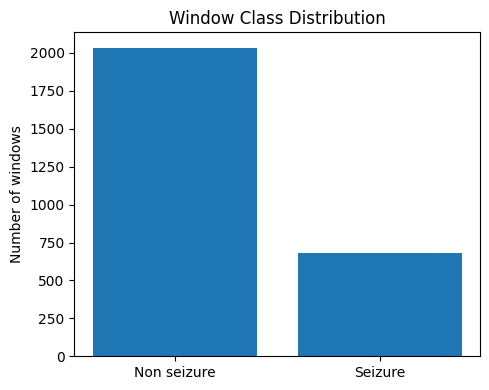

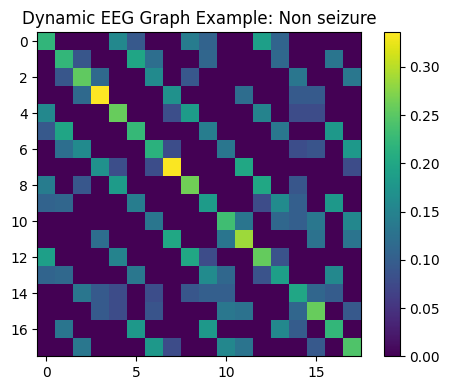

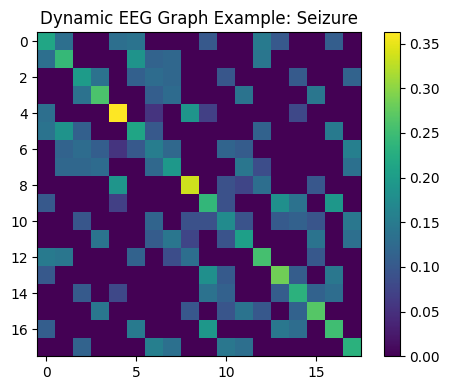

Saved visualization files:
/content/Final_EEG_Graph_Seizure_Project/results/class_distribution.png
/content/Final_EEG_Graph_Seizure_Project/results/graph_example_non_seizure.png
/content/Final_EEG_Graph_Seizure_Project/results/graph_example_seizure.png


In [9]:
plt.figure(figsize=(5, 4))
counts = pd.Series(y).map({0: "Non seizure", 1: "Seizure"}).value_counts()
plt.bar(counts.index, counts.values)
plt.title("Window Class Distribution")
plt.ylabel("Number of windows")
plt.tight_layout()

class_plot_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(class_plot_path, dpi=200)
plt.show()

non_idx = np.where(y == 0)[0][0]
seiz_idx = np.where(y == 1)[0][0]

plt.figure(figsize=(5, 4))
plt.imshow(A[non_idx])
plt.title("Dynamic EEG Graph Example: Non seizure")
plt.colorbar()
plt.tight_layout()

non_graph_path = RESULTS_DIR / "graph_example_non_seizure.png"
plt.savefig(non_graph_path, dpi=200)
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(A[seiz_idx])
plt.title("Dynamic EEG Graph Example: Seizure")
plt.colorbar()
plt.tight_layout()

seiz_graph_path = RESULTS_DIR / "graph_example_seizure.png"
plt.savefig(seiz_graph_path, dpi=200)
plt.show()

print("Saved visualization files:")
print(class_plot_path)
print(non_graph_path)
print(seiz_graph_path)

In [10]:
def safe_auc(y_true, prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, prob)
    except Exception:
        return np.nan


def compute_metrics_from_pred(y_true, prob, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall sensitivity": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc auc": safe_auc(y_true, prob),
        "false positive rate": fp / max(tn + fp, 1),
        "false negative rate": fn / max(tp + fn, 1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }


def compute_metrics_from_prob(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return compute_metrics_from_pred(y_true, prob, pred)


def tune_threshold_on_validation(y_val, val_prob, false_alarm_penalty=FALSE_ALARM_PENALTY):
    rows = []
    best = None
    best_score = -1e9

    for threshold in THRESHOLD_GRID:
        metrics = compute_metrics_from_prob(y_val, val_prob, threshold)
        selection_score = (
            metrics["f1"]
            - false_alarm_penalty * metrics["false positive rate"]
            + 0.03 * metrics["recall sensitivity"]
        )

        row = {
            "threshold": float(threshold),
            "selection score": float(selection_score),
            **metrics
        }

        rows.append(row)

        if selection_score > best_score:
            best_score = selection_score
            best = row

    return best, pd.DataFrame(rows)


print("Metric functions are ready.")
print("Threshold candidates:", len(THRESHOLD_GRID))

Metric functions are ready.
Threshold candidates: 81


In [11]:
class FlatDataset(Dataset):
    def __init__(self, X_input, labels, mask):
        self.X = torch.tensor(X_input[mask].reshape(np.sum(mask), -1), dtype=torch.float32)
        self.y = torch.tensor(labels[mask], dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


class GraphDataset(Dataset):
    def __init__(self, X_input, A_input, labels, mask, static_adj=None):
        self.X = torch.tensor(X_input[mask], dtype=torch.float32)
        self.y = torch.tensor(labels[mask], dtype=torch.long)

        if static_adj is None:
            self.A = torch.tensor(A_input[mask], dtype=torch.float32)
        else:
            static_batch = np.repeat(static_adj[None, :, :], np.sum(mask), axis=0)
            self.A = torch.tensor(static_batch, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.A[index], self.y[index]


def make_flat_loaders(X_input, split):
    train_loader = DataLoader(FlatDataset(X_input, y, split["train_mask"]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FlatDataset(X_input, y, split["val_eval_mask"]), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(FlatDataset(X_input, y, split["test_eval_mask"]), batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader


def make_graph_loaders(X_input, A_input, split, use_static=False, static_adj_local=None):
    if use_static:
        static_to_use = static_adj_local
    else:
        static_to_use = None

    train_loader = DataLoader(
        GraphDataset(X_input, A_input, y, split["train_mask"], static_adj=static_to_use),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        GraphDataset(X_input, A_input, y, split["val_eval_mask"], static_adj=static_to_use),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        GraphDataset(X_input, A_input, y, split["test_eval_mask"], static_adj=static_to_use),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_loader, val_loader, test_loader


print("Dataloaders are ready.")
print("Train windows:", int(np.sum(train_mask)))
print("Validation windows:", int(np.sum(val_eval_mask)))
print("Test windows:", int(np.sum(test_eval_mask)))

Dataloaders are ready.
Train windows: 1612
Validation windows: 204
Test windows: 736


In [12]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.35):
        super().__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Linear(hidden_dim // 2, 2)

    def forward(self, x, return_embedding=False):
        embedding = self.feature_layer(x)
        logits = self.classifier(embedding)

        if return_embedding:
            return logits, embedding

        return logits


class GraphConvLayer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, adj):
        x = torch.bmm(adj, x)
        return self.linear(x)


class GraphClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, embedding_dim=64, dropout=0.30):
        super().__init__()

        self.gcn1 = GraphConvLayer(input_dim, hidden_dim)
        self.gcn2 = GraphConvLayer(hidden_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim // 2, 2)
        )

    def forward(self, x, adj, return_embedding=False):
        x = F.relu(self.gcn1(x, adj))
        x = self.dropout(x)
        x = F.relu(self.gcn2(x, adj))

        embedding = x.mean(dim=1)
        logits = self.classifier(embedding)

        if return_embedding:
            return logits, embedding

        return logits


class DenseGraphAttentionLayer(nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.25, negative_slope=0.2):
        super().__init__()

        self.linear = nn.Linear(input_dim, output_dim, bias=False)
        self.attn_src = nn.Parameter(torch.empty(output_dim, 1))
        self.attn_dst = nn.Parameter(torch.empty(output_dim, 1))
        self.dropout = nn.Dropout(dropout)
        self.leaky_relu = nn.LeakyReLU(negative_slope)

        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.xavier_uniform_(self.attn_src)
        nn.init.xavier_uniform_(self.attn_dst)

    def forward(self, x, adj):
        h = self.linear(x)

        src_score = torch.matmul(h, self.attn_src)
        dst_score = torch.matmul(h, self.attn_dst)

        scores = src_score + dst_score.transpose(1, 2)
        scores = self.leaky_relu(scores)

        mask = adj > 0
        scores = scores.masked_fill(~mask, -1e9)

        attention = torch.softmax(scores, dim=-1)
        attention = self.dropout(attention)

        return torch.bmm(attention, h)


class GraphAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, embedding_dim=64, dropout=0.30):
        super().__init__()

        self.gat1 = DenseGraphAttentionLayer(input_dim, hidden_dim, dropout=dropout)
        self.gat2 = DenseGraphAttentionLayer(hidden_dim, embedding_dim, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim // 2, 2)
        )

    def forward(self, x, adj, return_embedding=False):
        x = F.elu(self.gat1(x, adj))
        x = self.dropout(x)
        x = F.elu(self.gat2(x, adj))

        embedding = x.mean(dim=1)
        logits = self.classifier(embedding)

        if return_embedding:
            return logits, embedding

        return logits


print("Model classes are ready.")
print("Models: MLP, GCN, GAT.")

Model classes are ready.
Models: MLP, GCN, GAT.


In [13]:
def get_class_weights(labels, positive_scale=0.85):
    counts = np.bincount(labels, minlength=2)
    weights = counts.sum() / (2.0 * np.maximum(counts, 1))

    weights[1] = weights[1] * positive_scale

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def evaluate_flat_model(model, loader, return_embeddings=False):
    model.eval()

    all_probs = []
    all_labels = []
    all_embeddings = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)

            if return_embeddings:
                logits, emb = model(xb, return_embedding=True)
                all_embeddings.append(emb.detach().cpu().numpy())
            else:
                logits = model(xb)

            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(yb.numpy())

    if return_embeddings:
        return np.array(all_labels), np.array(all_probs), np.concatenate(all_embeddings, axis=0)

    return np.array(all_labels), np.array(all_probs)


def evaluate_graph_model(model, loader, return_embeddings=False):
    model.eval()

    all_probs = []
    all_labels = []
    all_embeddings = []

    with torch.no_grad():
        for xb, ab, yb in loader:
            xb = xb.to(DEVICE)
            ab = ab.to(DEVICE)

            if return_embeddings:
                logits, emb = model(xb, ab, return_embedding=True)
                all_embeddings.append(emb.detach().cpu().numpy())
            else:
                logits = model(xb, ab)

            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(yb.numpy())

    if return_embeddings:
        return np.array(all_labels), np.array(all_probs), np.concatenate(all_embeddings, axis=0)

    return np.array(all_labels), np.array(all_probs)


def train_flat_model(model, train_loader, val_loader, train_labels, model_name, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(weight=get_class_weights(train_labels))

    best_state = None
    best_score = -1e9
    patience_counter = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(yb)

        val_labels, val_probs = evaluate_flat_model(model, val_loader)
        best_val, _ = tune_threshold_on_validation(val_labels, val_probs)

        avg_loss = total_loss / max(len(train_loader.dataset), 1)

        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "validation f1": best_val["f1"],
            "validation false positive rate": best_val["false positive rate"],
            "validation threshold": best_val["threshold"],
            "validation score": best_val["selection score"]
        })

        if epoch == 1 or epoch % 5 == 0:
            print(model_name, "epoch", epoch, "loss", round(avg_loss, 4), "validation f1", round(best_val["f1"], 4))

        if best_val["selection score"] > best_score:
            best_score = best_val["selection score"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(model_name, "early stopping at epoch", epoch)
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def train_graph_model(model, train_loader, val_loader, train_labels, model_name, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(weight=get_class_weights(train_labels))

    best_state = None
    best_score = -1e9
    patience_counter = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, ab, yb in train_loader:
            xb = xb.to(DEVICE)
            ab = ab.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb, ab)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(yb)

        val_labels, val_probs = evaluate_graph_model(model, val_loader)
        best_val, _ = tune_threshold_on_validation(val_labels, val_probs)

        avg_loss = total_loss / max(len(train_loader.dataset), 1)

        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "validation f1": best_val["f1"],
            "validation false positive rate": best_val["false positive rate"],
            "validation threshold": best_val["threshold"],
            "validation score": best_val["selection score"]
        })

        if epoch == 1 or epoch % 5 == 0:
            print(model_name, "epoch", epoch, "loss", round(avg_loss, 4), "validation f1", round(best_val["f1"], 4))

        if best_val["selection score"] > best_score:
            best_score = best_val["selection score"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(model_name, "early stopping at epoch", epoch)
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def evaluate_model_with_validation_threshold(method_name, val_labels, val_probs, test_labels, test_probs):
    best_val, threshold_table = tune_threshold_on_validation(val_labels, val_probs)
    threshold = best_val["threshold"]
    test_metrics = compute_metrics_from_prob(test_labels, test_probs, threshold)

    return {
        "method": method_name,
        "threshold": threshold,
        "validation": best_val,
        "test": test_metrics,
        "threshold table": threshold_table
    }


print("Training utilities are ready.")

Training utilities are ready.


In [14]:
results = {}
validation_results = {}
threshold_records = {}
prob_store = {}
model_store = {}

X_flat = X_scaled.reshape(X_scaled.shape[0], -1)

X_train = X_flat[train_mask]
X_val = X_flat[val_eval_mask]
X_test = X_flat[test_eval_mask]

y_train = y[train_mask]
y_val = y[val_eval_mask]
y_test = y[test_eval_mask]

print("Training traditional baselines.")
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

baseline_models = {
    "Logistic Regression EEG Features": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest EEG Features": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "SVM RBF EEG Features": SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
}

for name, model in baseline_models.items():
    print("Training:", name)

    model.fit(X_train, y_train)

    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    eval_pack = evaluate_model_with_validation_threshold(name, y_val, val_probs, y_test, test_probs)

    results[name] = eval_pack["test"]
    validation_results[name] = eval_pack["validation"]
    threshold_records[name] = eval_pack["threshold"]

    prob_store[name] = {
        "val labels": y_val,
        "val probs": val_probs,
        "test labels": y_test,
        "test probs": test_probs
    }

    model_store[name] = model

    print(name, "test f1:", round(eval_pack["test"]["f1"], 4))

traditional_df = pd.DataFrame(results).T
display(traditional_df)

Training traditional baselines.
Train: (1612, 180) Validation: (204, 180) Test: (736, 180)
Training: Logistic Regression EEG Features
Logistic Regression EEG Features test f1: 0.7269
Training: Random Forest EEG Features
Random Forest EEG Features test f1: 0.6565
Training: SVM RBF EEG Features
SVM RBF EEG Features test f1: 0.7703


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Logistic Regression EEG Features,0.835598,0.703057,0.752336,0.869732,0.726862,0.875756,0.130268,0.247664,454.0,68.0,53.0,161.0
Random Forest EEG Features,0.724185,0.514589,0.906542,0.649425,0.656514,0.928376,0.350575,0.093458,339.0,183.0,20.0,194.0
SVM RBF EEG Features,0.861413,0.743478,0.799065,0.886973,0.770270,0.904268,0.113027,0.200935,463.0,59.0,43.0,171.0


In [15]:
print("Training MLP baseline.")

train_loader, val_loader, test_loader = make_flat_loaders(X_scaled, primary_split)

input_dim = X_scaled.shape[1] * X_scaled.shape[2]

mlp_model = MLPClassifier(input_dim=input_dim)
mlp_model, mlp_history = train_flat_model(
    mlp_model,
    train_loader,
    val_loader,
    y_train,
    "MLP EEG Features"
)

val_labels, val_probs = evaluate_flat_model(mlp_model, val_loader)
test_labels, test_probs = evaluate_flat_model(mlp_model, test_loader)

eval_pack = evaluate_model_with_validation_threshold(
    "MLP EEG Features",
    val_labels,
    val_probs,
    test_labels,
    test_probs
)

results["MLP EEG Features"] = eval_pack["test"]
validation_results["MLP EEG Features"] = eval_pack["validation"]
threshold_records["MLP EEG Features"] = eval_pack["threshold"]

prob_store["MLP EEG Features"] = {
    "val labels": val_labels,
    "val probs": val_probs,
    "test labels": test_labels,
    "test probs": test_probs
}

model_store["MLP EEG Features"] = mlp_model

print("MLP finished.")
display(pd.DataFrame(results).T.loc[["MLP EEG Features"]])
display(mlp_history.tail())

Training MLP baseline.
MLP EEG Features epoch 1 loss 0.4555 validation f1 0.8871
MLP EEG Features epoch 5 loss 0.1392 validation f1 0.0923
MLP EEG Features epoch 10 loss 0.0704 validation f1 0.0317
MLP EEG Features early stopping at epoch 10
MLP finished.


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
MLP EEG Features,0.809783,0.607558,0.976636,0.741379,0.749104,0.973816,0.258621,0.023364,387.0,135.0,5.0,209.0


,epoch,loss,validation f1,validation false positive rate,validation threshold,validation score
5,6,0.113987,0.092308,0.006993,0.10,0.092385
6,7,0.103791,0.031746,0.006993,0.10,0.030839
7,8,0.083498,0.032258,0.000000,0.11,0.032750
8,9,0.089831,0.000000,0.000000,0.45,0.000000
9,10,0.070388,0.031746,0.006993,0.10,0.030839


In [16]:
print("Training Static GCN baseline.")

train_loader, val_loader, test_loader = make_graph_loaders(
    X_scaled,
    A,
    primary_split,
    use_static=True,
    static_adj_local=static_adj
)

static_gcn = GraphClassifier(input_dim=X_scaled.shape[-1])
static_gcn, static_history = train_graph_model(
    static_gcn,
    train_loader,
    val_loader,
    y_train,
    "Static GCN"
)

val_labels, val_probs = evaluate_graph_model(static_gcn, val_loader)
test_labels, test_probs = evaluate_graph_model(static_gcn, test_loader)

eval_pack = evaluate_model_with_validation_threshold("Static GCN", val_labels, val_probs, test_labels, test_probs)

results["Static GCN"] = eval_pack["test"]
validation_results["Static GCN"] = eval_pack["validation"]
threshold_records["Static GCN"] = eval_pack["threshold"]

prob_store["Static GCN"] = {
    "val labels": val_labels,
    "val probs": val_probs,
    "test labels": test_labels,
    "test probs": test_probs
}

model_store["Static GCN"] = static_gcn

print("Static GCN finished.")
display(pd.DataFrame(results).T.loc[["Static GCN"]])
display(static_history.tail())

Training Static GCN baseline.
Static GCN epoch 1 loss 0.6281 validation f1 0.9062
Static GCN epoch 5 loss 0.3602 validation f1 0.7895
Static GCN epoch 10 loss 0.2673 validation f1 0.5412
Static GCN early stopping at epoch 10
Static GCN finished.


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Static GCN,0.771739,0.560209,1.0,0.678161,0.718121,0.981622,0.321839,0.0,354.0,168.0,0.0,214.0


,epoch,loss,validation f1,validation false positive rate,validation threshold,validation score
5,6,0.340209,0.789474,0.055944,0.1,0.800416
6,7,0.321630,0.756757,0.055944,0.1,0.766224
7,8,0.310730,0.698113,0.055944,0.1,0.705121
8,9,0.286649,0.625000,0.034965,0.1,0.632761
9,10,0.267320,0.541176,0.006993,0.1,0.551089


In [17]:
print("Training Dynamic GCN baseline.")

train_loader, val_loader, test_loader = make_graph_loaders(
    X_scaled,
    A,
    primary_split,
    use_static=False
)

dynamic_gcn = GraphClassifier(input_dim=X_scaled.shape[-1])
dynamic_gcn, dynamic_gcn_history = train_graph_model(
    dynamic_gcn,
    train_loader,
    val_loader,
    y_train,
    "Dynamic GCN"
)

val_labels, val_probs = evaluate_graph_model(dynamic_gcn, val_loader)
test_labels, test_probs = evaluate_graph_model(dynamic_gcn, test_loader)

eval_pack = evaluate_model_with_validation_threshold("Dynamic GCN", val_labels, val_probs, test_labels, test_probs)

results["Dynamic GCN"] = eval_pack["test"]
validation_results["Dynamic GCN"] = eval_pack["validation"]
threshold_records["Dynamic GCN"] = eval_pack["threshold"]

prob_store["Dynamic GCN"] = {
    "val labels": val_labels,
    "val probs": val_probs,
    "test labels": test_labels,
    "test probs": test_probs
}

model_store["Dynamic GCN"] = dynamic_gcn

print("Dynamic GCN finished.")
display(pd.DataFrame(results).T.loc[["Dynamic GCN"]])
display(dynamic_gcn_history.tail())

Training Dynamic GCN baseline.
Dynamic GCN epoch 1 loss 0.6169 validation f1 0.9048
Dynamic GCN epoch 5 loss 0.3558 validation f1 0.7895
Dynamic GCN epoch 10 loss 0.2861 validation f1 0.5581
Dynamic GCN early stopping at epoch 10
Dynamic GCN finished.


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Dynamic GCN,0.847826,0.659375,0.985981,0.791188,0.790262,0.98181,0.208812,0.014019,413.0,109.0,3.0,211.0


,epoch,loss,validation f1,validation false positive rate,validation threshold,validation score
5,6,0.346217,0.711538,0.041958,0.1,0.721344
6,7,0.337902,0.693069,0.034965,0.1,0.703289
7,8,0.324433,0.666667,0.020979,0.1,0.678209
8,9,0.306167,0.652174,0.006993,0.1,0.665529
9,10,0.286072,0.558140,0.006993,0.1,0.568544


In [18]:
print("Training Dynamic GAT baseline.")

train_loader, val_loader, test_loader = make_graph_loaders(
    X_scaled,
    A,
    primary_split,
    use_static=False
)

dynamic_gat = GraphAttentionClassifier(input_dim=X_scaled.shape[-1])
dynamic_gat, dynamic_gat_history = train_graph_model(
    dynamic_gat,
    train_loader,
    val_loader,
    y_train,
    "Dynamic GAT"
)

val_labels, val_probs = evaluate_graph_model(dynamic_gat, val_loader)
test_labels, test_probs = evaluate_graph_model(dynamic_gat, test_loader)

eval_pack = evaluate_model_with_validation_threshold("Dynamic GAT", val_labels, val_probs, test_labels, test_probs)

results["Dynamic GAT"] = eval_pack["test"]
validation_results["Dynamic GAT"] = eval_pack["validation"]
threshold_records["Dynamic GAT"] = eval_pack["threshold"]

prob_store["Dynamic GAT"] = {
    "val labels": val_labels,
    "val probs": val_probs,
    "test labels": test_labels,
    "test probs": test_probs
}

model_store["Dynamic GAT"] = dynamic_gat

print("Dynamic GAT finished.")
display(pd.DataFrame(results).T.loc[["Dynamic GAT"]])
display(dynamic_gat_history.tail())

Training Dynamic GAT baseline.
Dynamic GAT epoch 1 loss 0.5318 validation f1 0.9062
Dynamic GAT epoch 5 loss 0.3571 validation f1 0.9076
Dynamic GAT epoch 10 loss 0.3131 validation f1 0.7477
Dynamic GAT early stopping at epoch 13
Dynamic GAT finished.


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Dynamic GAT,0.828804,0.631737,0.985981,0.764368,0.770073,0.985265,0.235632,0.014019,399.0,123.0,3.0,211.0


,epoch,loss,validation f1,validation false positive rate,validation threshold,validation score
8,9,0.318702,0.770642,0.041958,0.10,0.782906
9,10,0.313096,0.747664,0.041958,0.11,0.758944
10,11,0.301815,0.736842,0.076923,0.10,0.742113
11,12,0.290933,0.616822,0.090909,0.10,0.614870
12,13,0.301313,0.648148,0.083916,0.10,0.648578


In [19]:
dpc_rows = []

print("Training Patient Calibrated GAT alpha sweep.")

for alpha in DPC_ALPHA_VALUES:
    method_name = f"Patient Calibrated GAT alpha {alpha}"

    print("Starting:", method_name)

    train_loader, val_loader, test_loader = make_graph_loaders(
        X_scaled,
        A_dpc_dict[alpha],
        primary_split,
        use_static=False
    )

    model = GraphAttentionClassifier(input_dim=X_scaled.shape[-1])
    model, history = train_graph_model(
        model,
        train_loader,
        val_loader,
        y_train,
        method_name
    )

    val_labels, val_probs = evaluate_graph_model(model, val_loader)
    test_labels, test_probs = evaluate_graph_model(model, test_loader)

    eval_pack = evaluate_model_with_validation_threshold(method_name, val_labels, val_probs, test_labels, test_probs)

    results[method_name] = eval_pack["test"]
    validation_results[method_name] = eval_pack["validation"]
    threshold_records[method_name] = eval_pack["threshold"]

    prob_store[method_name] = {
        "val labels": val_labels,
        "val probs": val_probs,
        "test labels": test_labels,
        "test probs": test_probs
    }

    model_store[method_name] = model

    row = {
        "method": method_name,
        "alpha": alpha,
        "threshold": eval_pack["threshold"],
        **eval_pack["test"]
    }

    dpc_rows.append(row)

    print(method_name, "test f1:", round(eval_pack["test"]["f1"], 4))

dpc_df = pd.DataFrame(dpc_rows)
dpc_path = RESULTS_DIR / "patient_calibrated_gat_alpha_sweep.csv"
dpc_df.to_csv(dpc_path, index=False)

print("Patient Calibrated GAT sweep saved to:", dpc_path)
display(dpc_df.sort_values(by="f1", ascending=False))

Training Patient Calibrated GAT alpha sweep.
Starting: Patient Calibrated GAT alpha 0.25
Patient Calibrated GAT alpha 0.25 epoch 1 loss 0.5386 validation f1 0.896
Patient Calibrated GAT alpha 0.25 epoch 5 loss 0.3632 validation f1 0.9032
Patient Calibrated GAT alpha 0.25 epoch 10 loss 0.3096 validation f1 0.8547
Patient Calibrated GAT alpha 0.25 early stopping at epoch 11
Patient Calibrated GAT alpha 0.25 test f1: 0.6914
Starting: Patient Calibrated GAT alpha 0.5
Patient Calibrated GAT alpha 0.5 epoch 1 loss 0.5205 validation f1 0.9062
Patient Calibrated GAT alpha 0.5 epoch 5 loss 0.3304 validation f1 0.5455
Patient Calibrated GAT alpha 0.5 epoch 10 loss 0.2744 validation f1 0.5116
Patient Calibrated GAT alpha 0.5 early stopping at epoch 10
Patient Calibrated GAT alpha 0.5 test f1: 0.6959
Starting: Patient Calibrated GAT alpha 0.75
Patient Calibrated GAT alpha 0.75 epoch 1 loss 0.5757 validation f1 0.8908
Patient Calibrated GAT alpha 0.75 epoch 5 loss 0.3674 validation f1 0.9076
Patien

,method,alpha,threshold,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
2,Patient Calibrated GAT alpha 0.75,0.75,0.11,0.797554,0.590028,0.995327,0.716475,0.740870,0.983009,0.283525,0.004673,374,148,1,213
5,Patient Calibrated GAT alpha 2.0,2.00,0.10,0.771739,0.560526,0.995327,0.680077,0.717172,0.981514,0.319923,0.004673,355,167,1,213
1,Patient Calibrated GAT alpha 0.5,0.50,0.10,0.745924,0.533666,1.000000,0.641762,0.695935,0.985140,0.358238,0.000000,335,187,0,214
3,Patient Calibrated GAT alpha 1.0,1.00,0.17,0.744565,0.532338,1.000000,0.639847,0.694805,0.981344,0.360153,0.000000,334,188,0,214
0,Patient Calibrated GAT alpha 0.25,0.25,0.10,0.740489,0.528395,1.000000,0.634100,0.691438,0.981890,0.365900,0.000000,331,191,0,214
4,Patient Calibrated GAT alpha 1.5,1.50,0.12,0.661685,0.462203,1.000000,0.522989,0.632201,0.980807,0.477011,0.000000,273,249,0,214


In [20]:
hybrid_rows = []

print("Training Hybrid DPC GAT alpha sweep.")
print("Hybrid means graph calibrated adjacency plus patient deviation node feature.")

for alpha in DPC_ALPHA_VALUES:
    method_name = f"Hybrid DPC GAT alpha {alpha}"

    print("Starting:", method_name)

    train_loader, val_loader, test_loader = make_graph_loaders(
        X_hybrid,
        A_dpc_dict[alpha],
        primary_split,
        use_static=False
    )

    model = GraphAttentionClassifier(input_dim=X_hybrid.shape[-1])
    model, history = train_graph_model(
        model,
        train_loader,
        val_loader,
        y_train,
        method_name
    )

    val_labels, val_probs = evaluate_graph_model(model, val_loader)
    test_labels, test_probs = evaluate_graph_model(model, test_loader)

    eval_pack = evaluate_model_with_validation_threshold(method_name, val_labels, val_probs, test_labels, test_probs)

    results[method_name] = eval_pack["test"]
    validation_results[method_name] = eval_pack["validation"]
    threshold_records[method_name] = eval_pack["threshold"]

    prob_store[method_name] = {
        "val labels": val_labels,
        "val probs": val_probs,
        "test labels": test_labels,
        "test probs": test_probs
    }

    model_store[method_name] = model

    row = {
        "method": method_name,
        "alpha": alpha,
        "threshold": eval_pack["threshold"],
        **eval_pack["test"]
    }

    hybrid_rows.append(row)

    print(method_name, "test f1:", round(eval_pack["test"]["f1"], 4))

hybrid_df = pd.DataFrame(hybrid_rows)
hybrid_path = RESULTS_DIR / "hybrid_dpc_gat_alpha_sweep.csv"
hybrid_df.to_csv(hybrid_path, index=False)

print("Hybrid DPC GAT sweep saved to:", hybrid_path)
display(hybrid_df.sort_values(by="f1", ascending=False))

Training Hybrid DPC GAT alpha sweep.
Hybrid means graph calibrated adjacency plus patient deviation node feature.
Starting: Hybrid DPC GAT alpha 0.25
Hybrid DPC GAT alpha 0.25 epoch 1 loss 0.5364 validation f1 0.9147
Hybrid DPC GAT alpha 0.25 epoch 5 loss 0.2915 validation f1 0.6903
Hybrid DPC GAT alpha 0.25 epoch 10 loss 0.2576 validation f1 0.5965
Hybrid DPC GAT alpha 0.25 early stopping at epoch 10
Hybrid DPC GAT alpha 0.25 test f1: 0.632
Starting: Hybrid DPC GAT alpha 0.5
Hybrid DPC GAT alpha 0.5 epoch 1 loss 0.5146 validation f1 0.9194
Hybrid DPC GAT alpha 0.5 epoch 5 loss 0.3134 validation f1 0.9194
Hybrid DPC GAT alpha 0.5 epoch 10 loss 0.286 validation f1 0.896
Hybrid DPC GAT alpha 0.5 early stopping at epoch 10
Hybrid DPC GAT alpha 0.5 test f1: 0.7487
Starting: Hybrid DPC GAT alpha 0.75
Hybrid DPC GAT alpha 0.75 epoch 1 loss 0.5359 validation f1 0.9062
Hybrid DPC GAT alpha 0.75 epoch 5 loss 0.3056 validation f1 0.8739
Hybrid DPC GAT alpha 0.75 epoch 10 loss 0.2863 validation f

,method,alpha,threshold,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
1,Hybrid DPC GAT alpha 0.5,0.50,0.24,0.808424,0.605187,0.981308,0.737548,0.748663,0.970933,0.262452,0.018692,385,137,4,210
2,Hybrid DPC GAT alpha 0.75,0.75,0.10,0.767663,0.556728,0.985981,0.678161,0.711636,0.967970,0.321839,0.014019,354,168,3,211
4,Hybrid DPC GAT alpha 1.5,1.50,0.30,0.743207,0.531486,0.985981,0.643678,0.690671,0.946638,0.356322,0.014019,336,186,3,211
5,Hybrid DPC GAT alpha 2.0,2.00,0.10,0.740489,0.528822,0.985981,0.639847,0.688418,0.951624,0.360153,0.014019,334,188,3,211
3,Hybrid DPC GAT alpha 1.0,1.00,0.11,0.736413,0.524876,0.985981,0.634100,0.685065,0.971148,0.365900,0.014019,331,191,3,211
0,Hybrid DPC GAT alpha 0.25,0.25,0.14,0.663043,0.463043,0.995327,0.526820,0.632047,0.970172,0.473180,0.004673,275,247,1,213


In [21]:
print("Building validation tuned ensemble.")

results_df_temp = pd.DataFrame(results).T
validation_df_temp = pd.DataFrame(validation_results).T

candidate_methods = []

for method in ["Dynamic GCN", "Dynamic GAT"]:
    if method in prob_store:
        candidate_methods.append(method)

top_dpc = dpc_df.sort_values(by="f1", ascending=False)["method"].head(2).tolist()
top_hybrid = hybrid_df.sort_values(by="f1", ascending=False)["method"].head(2).tolist()

candidate_methods.extend(top_dpc)
candidate_methods.extend(top_hybrid)
candidate_methods = list(dict.fromkeys(candidate_methods))

print("Ensemble candidate methods:")
for method in candidate_methods:
    print(method)

base_val_labels = prob_store[candidate_methods[0]]["val labels"]
base_test_labels = prob_store[candidate_methods[0]]["test labels"]

for method in candidate_methods:
    if not np.array_equal(base_val_labels, prob_store[method]["val labels"]):
        raise RuntimeError("Validation labels do not match.")
    if not np.array_equal(base_test_labels, prob_store[method]["test labels"]):
        raise RuntimeError("Test labels do not match.")

ensemble_rng = np.random.default_rng(SEED)
weight_sets = []

for i in range(len(candidate_methods)):
    weights = np.zeros(len(candidate_methods))
    weights[i] = 1.0
    weight_sets.append(weights)

for _ in range(ENSEMBLE_RANDOM_SEARCHES):
    weights = ensemble_rng.dirichlet(np.ones(len(candidate_methods)))
    weight_sets.append(weights)

ensemble_rows = []
ensemble_outputs = {}

for weights in weight_sets:
    fused_val_probs = np.zeros_like(base_val_labels, dtype=np.float32)
    fused_test_probs = np.zeros_like(base_test_labels, dtype=np.float32)

    for weight, method in zip(weights, candidate_methods):
        fused_val_probs += weight * prob_store[method]["val probs"]
        fused_test_probs += weight * prob_store[method]["test probs"]

    best_val, threshold_table = tune_threshold_on_validation(base_val_labels, fused_val_probs)

    threshold = best_val["threshold"]
    test_metrics = compute_metrics_from_prob(base_test_labels, fused_test_probs, threshold)

    method_name = "Validation Tuned Graph Ensemble"

    row = {
        "threshold": threshold,
        "validation score": best_val["selection score"],
        "validation f1": best_val["f1"],
        "validation false positive rate": best_val["false positive rate"],
        **test_metrics
    }

    for method, weight in zip(candidate_methods, weights):
        row["weight " + method] = float(weight)

    ensemble_rows.append(row)

    ensemble_outputs[len(ensemble_rows) - 1] = {
        "labels": base_test_labels,
        "probs": fused_test_probs,
        "preds": (fused_test_probs >= threshold).astype(int),
        "threshold": threshold,
        "weights": weights,
        "metrics": test_metrics
    }

ensemble_df = pd.DataFrame(ensemble_rows)
ensemble_df = ensemble_df.sort_values(by="f1", ascending=False)

best_ensemble_index = int(ensemble_df.index[0])
best_ensemble_output = ensemble_outputs[best_ensemble_index]

results["Validation Tuned Graph Ensemble"] = best_ensemble_output["metrics"]
validation_results["Validation Tuned Graph Ensemble"] = {
    "threshold": best_ensemble_output["threshold"],
    "selection score": float(ensemble_df.loc[best_ensemble_index, "validation score"])
}
threshold_records["Validation Tuned Graph Ensemble"] = best_ensemble_output["threshold"]

prob_store["Validation Tuned Graph Ensemble"] = {
    "val labels": base_val_labels,
    "val probs": None,
    "test labels": best_ensemble_output["labels"],
    "test probs": best_ensemble_output["probs"],
    "test preds": best_ensemble_output["preds"]
}

ensemble_path = RESULTS_DIR / "validation_tuned_graph_ensemble_search.csv"
ensemble_df.to_csv(ensemble_path, index=False)

print("Ensemble search saved to:", ensemble_path)
print("Best ensemble result:")
display(ensemble_df.head(1).T)

Building validation tuned ensemble.
Ensemble candidate methods:
Dynamic GCN
Dynamic GAT
Patient Calibrated GAT alpha 0.75
Patient Calibrated GAT alpha 2.0
Hybrid DPC GAT alpha 0.5
Hybrid DPC GAT alpha 0.75
Ensemble search saved to: /content/Final_EEG_Graph_Seizure_Project/results/validation_tuned_graph_ensemble_search.csv
Best ensemble result:


,251
threshold,0.240000
validation score,0.929718
validation f1,0.910569
validation false positive rate,0.041958
accuracy,0.862772
precision,0.684039
recall sensitivity,0.981308
specificity,0.814176
f1,0.806142
roc auc,0.983582


In [22]:
final_results_df = pd.DataFrame(results).T

display_columns = [
    "accuracy",
    "precision",
    "recall sensitivity",
    "specificity",
    "f1",
    "roc auc",
    "false positive rate",
    "false negative rate",
    "tn",
    "fp",
    "fn",
    "tp"
]

final_results_df = final_results_df[display_columns]
final_results_df = final_results_df.sort_values(by="f1", ascending=False)

final_results_path = RESULTS_DIR / "final_model_comparison.csv"
final_results_df.to_csv(final_results_path)

print("Final comparison saved to:", final_results_path)
display(final_results_df)

Final comparison saved to: /content/Final_EEG_Graph_Seizure_Project/results/final_model_comparison.csv


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Validation Tuned Graph Ensemble,0.862772,0.684039,0.981308,0.814176,0.806142,0.983582,0.185824,0.018692,425.0,97.0,4.0,210.0
Dynamic GCN,0.847826,0.659375,0.985981,0.791188,0.790262,0.981810,0.208812,0.014019,413.0,109.0,3.0,211.0
SVM RBF EEG Features,0.861413,0.743478,0.799065,0.886973,0.770270,0.904268,0.113027,0.200935,463.0,59.0,43.0,171.0
Dynamic GAT,0.828804,0.631737,0.985981,0.764368,0.770073,0.985265,0.235632,0.014019,399.0,123.0,3.0,211.0
MLP EEG Features,0.809783,0.607558,0.976636,0.741379,0.749104,0.973816,0.258621,0.023364,387.0,135.0,5.0,209.0
Hybrid DPC GAT alpha 0.5,0.808424,0.605187,0.981308,0.737548,0.748663,0.970933,0.262452,0.018692,385.0,137.0,4.0,210.0
Patient Calibrated GAT alpha 0.75,0.797554,0.590028,0.995327,0.716475,0.740870,0.983009,0.283525,0.004673,374.0,148.0,1.0,213.0
Logistic Regression EEG Features,0.835598,0.703057,0.752336,0.869732,0.726862,0.875756,0.130268,0.247664,454.0,68.0,53.0,161.0
Static GCN,0.771739,0.560209,1.000000,0.678161,0.718121,0.981622,0.321839,0.000000,354.0,168.0,0.0,214.0
Patient Calibrated GAT alpha 2.0,0.771739,0.560526,0.995327,0.680077,0.717172,0.981514,0.319923,0.004673,355.0,167.0,1.0,213.0


In [23]:
best_dpc_method = dpc_df.sort_values(by="f1", ascending=False).iloc[0]["method"]
best_hybrid_method = hybrid_df.sort_values(by="f1", ascending=False).iloc[0]["method"]

ablation_methods = [
    "Logistic Regression EEG Features",
    "Random Forest EEG Features",
    "SVM RBF EEG Features",
    "MLP EEG Features",
    "Static GCN",
    "Dynamic GCN",
    "Dynamic GAT",
    best_dpc_method,
    best_hybrid_method,
    "Validation Tuned Graph Ensemble"
]

ablation_methods = [m for m in ablation_methods if m in final_results_df.index]

ablation_df = final_results_df.loc[ablation_methods][
    [
        "accuracy",
        "precision",
        "recall sensitivity",
        "specificity",
        "f1",
        "roc auc",
        "false positive rate"
    ]
]

ablation_path = RESULTS_DIR / "main_ablation_table.csv"
ablation_df.to_csv(ablation_path)

print("Ablation table saved to:", ablation_path)
print("Best patient calibrated method:", best_dpc_method)
print("Best hybrid patient calibrated method:", best_hybrid_method)
display(ablation_df)

Ablation table saved to: /content/Final_EEG_Graph_Seizure_Project/results/main_ablation_table.csv
Best patient calibrated method: Patient Calibrated GAT alpha 0.75
Best hybrid patient calibrated method: Hybrid DPC GAT alpha 0.5


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate
Logistic Regression EEG Features,0.835598,0.703057,0.752336,0.869732,0.726862,0.875756,0.130268
Random Forest EEG Features,0.724185,0.514589,0.906542,0.649425,0.656514,0.928376,0.350575
SVM RBF EEG Features,0.861413,0.743478,0.799065,0.886973,0.770270,0.904268,0.113027
MLP EEG Features,0.809783,0.607558,0.976636,0.741379,0.749104,0.973816,0.258621
Static GCN,0.771739,0.560209,1.000000,0.678161,0.718121,0.981622,0.321839
Dynamic GCN,0.847826,0.659375,0.985981,0.791188,0.790262,0.981810,0.208812
Dynamic GAT,0.828804,0.631737,0.985981,0.764368,0.770073,0.985265,0.235632
Patient Calibrated GAT alpha 0.75,0.797554,0.590028,0.995327,0.716475,0.740870,0.983009,0.283525
Hybrid DPC GAT alpha 0.5,0.808424,0.605187,0.981308,0.737548,0.748663,0.970933,0.262452
Validation Tuned Graph Ensemble,0.862772,0.684039,0.981308,0.814176,0.806142,0.983582,0.185824


In [24]:
final_model_name = final_results_df.index[0]

print("Final selected method:", final_model_name)
display(final_results_df.loc[[final_model_name]])

if final_model_name == "Validation Tuned Graph Ensemble":
    final_test_labels = best_ensemble_output["labels"]
    final_test_probs = best_ensemble_output["probs"]
    final_test_preds = best_ensemble_output["preds"]
    final_threshold = best_ensemble_output["threshold"]
else:
    final_test_labels = prob_store[final_model_name]["test labels"]
    final_test_probs = prob_store[final_model_name]["test probs"]
    final_threshold = threshold_records[final_model_name]
    final_test_preds = (final_test_probs >= final_threshold).astype(int)

test_indices = np.where(test_eval_mask)[0]
test_patient_ids = patient_ids[test_indices]

patient_rows = []

for patient in sorted(pd.Series(test_patient_ids).unique()):
    local_mask = test_patient_ids == patient

    patient_metrics = compute_metrics_from_pred(
        final_test_labels[local_mask],
        final_test_probs[local_mask],
        final_test_preds[local_mask]
    )

    patient_metrics["patient"] = patient
    patient_metrics["windows"] = int(np.sum(local_mask))
    patient_metrics["seizure windows"] = int(np.sum(final_test_labels[local_mask] == 1))
    patient_metrics["non seizure windows"] = int(np.sum(final_test_labels[local_mask] == 0))

    patient_rows.append(patient_metrics)

patient_results_df = pd.DataFrame(patient_rows)

patient_results_path = RESULTS_DIR / "patient_wise_final_results.csv"
patient_results_df.to_csv(patient_results_path, index=False)

print("Patient wise results saved to:", patient_results_path)
display(patient_results_df)

Final selected method: Validation Tuned Graph Ensemble


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Validation Tuned Graph Ensemble,0.862772,0.684039,0.981308,0.814176,0.806142,0.983582,0.185824,0.018692,425.0,97.0,4.0,210.0


Patient wise results saved to: /content/Final_EEG_Graph_Seizure_Project/results/patient_wise_final_results.csv


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp,patient,windows,seizure windows,non seizure windows
0,0.951923,0.942857,0.916667,0.970588,0.929577,0.995507,0.029412,0.083333,66,2,3,33,chb01,104,36,68
1,0.750000,0.532051,0.988095,0.655660,0.691667,0.976134,0.344340,0.011905,139,73,1,83,chb02,296,84,212
2,0.934524,0.810345,1.000000,0.909091,0.895238,0.996923,0.090909,0.000000,220,22,0,94,chb07,336,94,242


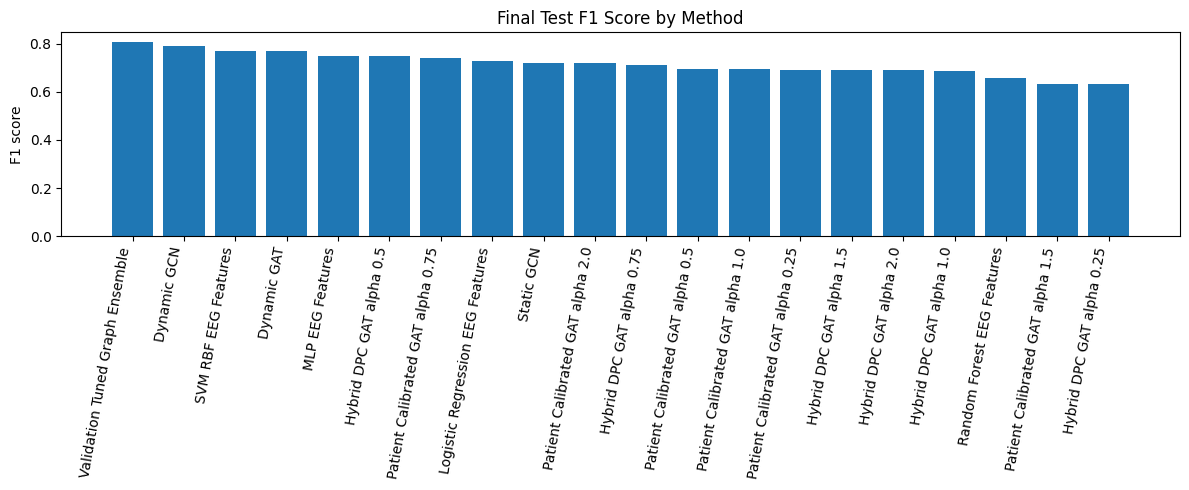

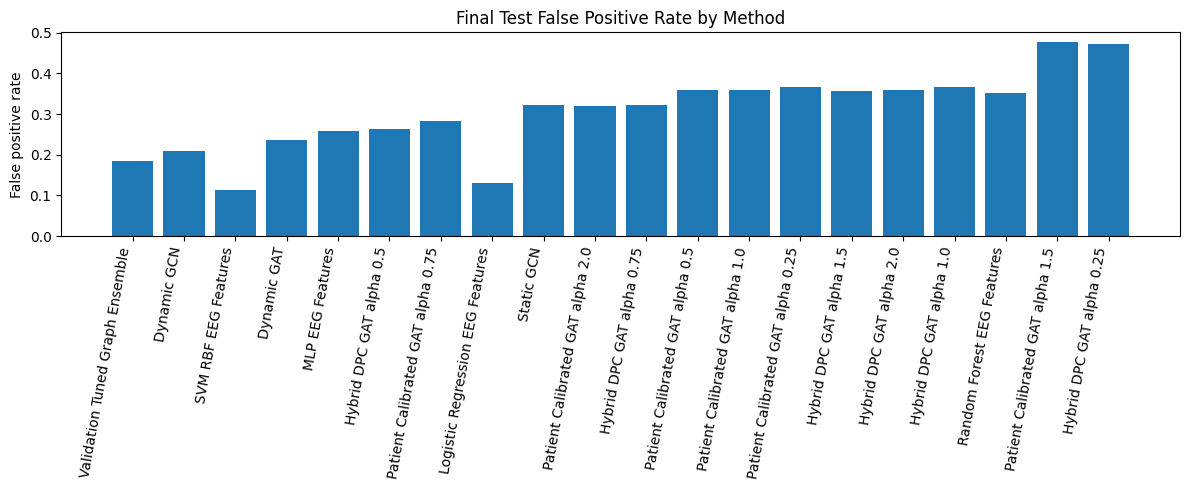

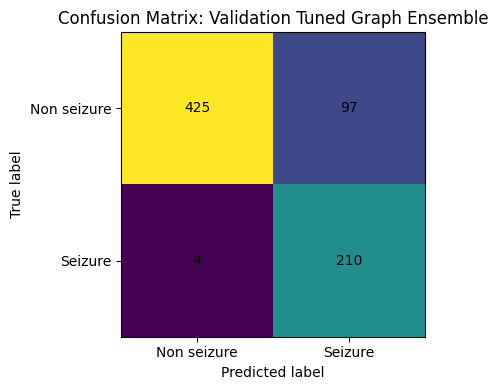

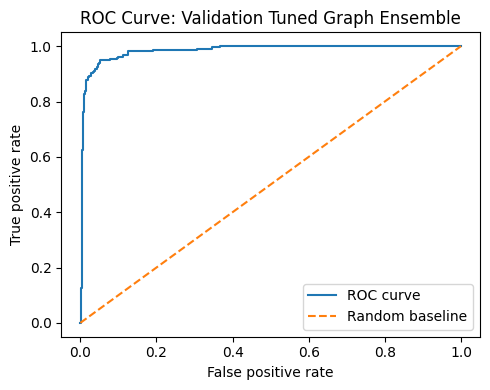

Saved plots:
/content/Final_EEG_Graph_Seizure_Project/results/final_test_f1_by_method.png
/content/Final_EEG_Graph_Seizure_Project/results/final_test_false_positive_rate_by_method.png
/content/Final_EEG_Graph_Seizure_Project/results/confusion_matrix_final_model.png
/content/Final_EEG_Graph_Seizure_Project/results/roc_curve_final_model.png


In [25]:
plot_df = final_results_df.reset_index().rename(columns={"index": "method"})

plt.figure(figsize=(12, 5))
plt.bar(plot_df["method"], plot_df["f1"])
plt.xticks(rotation=80, ha="right")
plt.ylabel("F1 score")
plt.title("Final Test F1 Score by Method")
plt.tight_layout()

f1_plot_path = RESULTS_DIR / "final_test_f1_by_method.png"
plt.savefig(f1_plot_path, dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["method"], plot_df["false positive rate"])
plt.xticks(rotation=80, ha="right")
plt.ylabel("False positive rate")
plt.title("Final Test False Positive Rate by Method")
plt.tight_layout()

fpr_plot_path = RESULTS_DIR / "final_test_false_positive_rate_by_method.png"
plt.savefig(fpr_plot_path, dpi=200)
plt.show()

cm = confusion_matrix(final_test_labels, final_test_preds, labels=[0, 1])

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix: " + final_model_name)
plt.xticks([0, 1], ["Non seizure", "Seizure"])
plt.yticks([0, 1], ["Non seizure", "Seizure"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()

cm_path = RESULTS_DIR / "confusion_matrix_final_model.png"
plt.savefig(cm_path, dpi=200)
plt.show()

fpr, tpr, _ = roc_curve(final_test_labels, final_test_probs)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve: " + final_model_name)
plt.legend()
plt.tight_layout()

roc_path = RESULTS_DIR / "roc_curve_final_model.png"
plt.savefig(roc_path, dpi=200)
plt.show()

print("Saved plots:")
print(f1_plot_path)
print(fpr_plot_path)
print(cm_path)
print(roc_path)

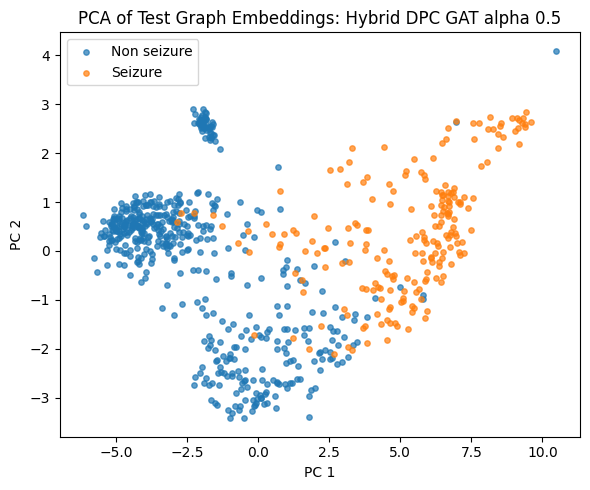

Embedding visualization saved to: /content/Final_EEG_Graph_Seizure_Project/results/pca_test_graph_embeddings.png


In [26]:
# I visualize the learned representation for the best available graph model.
# This figure helps explain whether seizure and non seizure windows separate in feature space.

embedding_model_name = None
embedding_model = None
embedding_X = None
embedding_A = None

for candidate in [best_hybrid_method, best_dpc_method, "Dynamic GAT", "Dynamic GCN"]:
    if candidate in model_store:
        embedding_model_name = candidate
        embedding_model = model_store[candidate]

        if candidate.startswith("Hybrid DPC GAT"):
            alpha = float(candidate.split("alpha")[-1].strip())
            embedding_X = X_hybrid
            embedding_A = A_dpc_dict[alpha]
        elif candidate.startswith("Patient Calibrated GAT"):
            alpha = float(candidate.split("alpha")[-1].strip())
            embedding_X = X_scaled
            embedding_A = A_dpc_dict[alpha]
        else:
            embedding_X = X_scaled
            embedding_A = A

        break

if embedding_model is not None:
    _, _, test_loader_embed = make_graph_loaders(
        embedding_X,
        embedding_A,
        primary_split,
        use_static=False
    )

    labels_embed, probs_embed, embeddings = evaluate_graph_model(
        embedding_model,
        test_loader_embed,
        return_embeddings=True
    )

    pca = PCA(n_components=2, random_state=SEED)
    emb_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(6, 5))
    plt.scatter(emb_2d[labels_embed == 0, 0], emb_2d[labels_embed == 0, 1], s=15, label="Non seizure", alpha=0.7)
    plt.scatter(emb_2d[labels_embed == 1, 0], emb_2d[labels_embed == 1, 1], s=15, label="Seizure", alpha=0.7)
    plt.title("PCA of Test Graph Embeddings: " + embedding_model_name)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.tight_layout()

    pca_path = RESULTS_DIR / "pca_test_graph_embeddings.png"
    plt.savefig(pca_path, dpi=200)
    plt.show()

    print("Embedding visualization saved to:", pca_path)
else:
    print("No graph model was available for embedding visualization.")

In [27]:
# I compare the final method with the strongest individual non ensemble model using bootstrap resampling.

individual_methods = [m for m in final_results_df.index if m != "Validation Tuned Graph Ensemble"]
strongest_individual = final_results_df.loc[individual_methods].sort_values(by="f1", ascending=False).index[0]

print("Strongest individual method:", strongest_individual)

baseline_labels = prob_store[strongest_individual]["test labels"]
baseline_probs = prob_store[strongest_individual]["test probs"]
baseline_threshold = threshold_records[strongest_individual]
baseline_preds = (baseline_probs >= baseline_threshold).astype(int)

if not np.array_equal(baseline_labels, final_test_labels):
    raise RuntimeError("Final and baseline labels do not match.")

bootstrap_rng = np.random.default_rng(SEED)
bootstrap_rows = []

n_test = len(final_test_labels)

for i in range(BOOTSTRAP_ROUNDS):
    idx = bootstrap_rng.choice(np.arange(n_test), size=n_test, replace=True)

    y_sample = final_test_labels[idx]

    final_metrics = compute_metrics_from_pred(y_sample, final_test_probs[idx], final_test_preds[idx])
    baseline_metrics = compute_metrics_from_pred(y_sample, baseline_probs[idx], baseline_preds[idx])

    bootstrap_rows.append({
        "final f1": final_metrics["f1"],
        "baseline f1": baseline_metrics["f1"],
        "f1 difference": final_metrics["f1"] - baseline_metrics["f1"],
        "final false positive rate": final_metrics["false positive rate"],
        "baseline false positive rate": baseline_metrics["false positive rate"],
        "false positive rate difference": final_metrics["false positive rate"] - baseline_metrics["false positive rate"],
        "final recall": final_metrics["recall sensitivity"],
        "baseline recall": baseline_metrics["recall sensitivity"],
        "recall difference": final_metrics["recall sensitivity"] - baseline_metrics["recall sensitivity"]
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)

bootstrap_summary = pd.DataFrame([
    {
        "metric": "f1 difference",
        "mean": bootstrap_df["f1 difference"].mean(),
        "lower 95": bootstrap_df["f1 difference"].quantile(0.025),
        "upper 95": bootstrap_df["f1 difference"].quantile(0.975)
    },
    {
        "metric": "false positive rate difference",
        "mean": bootstrap_df["false positive rate difference"].mean(),
        "lower 95": bootstrap_df["false positive rate difference"].quantile(0.025),
        "upper 95": bootstrap_df["false positive rate difference"].quantile(0.975)
    },
    {
        "metric": "recall difference",
        "mean": bootstrap_df["recall difference"].mean(),
        "lower 95": bootstrap_df["recall difference"].quantile(0.025),
        "upper 95": bootstrap_df["recall difference"].quantile(0.975)
    }
])

bootstrap_path = RESULTS_DIR / "bootstrap_final_vs_strongest_individual.csv"
bootstrap_summary_path = RESULTS_DIR / "bootstrap_summary.csv"

bootstrap_df.to_csv(bootstrap_path, index=False)
bootstrap_summary.to_csv(bootstrap_summary_path, index=False)

print("Bootstrap results saved to:", bootstrap_summary_path)
print("Probability final method has higher F1:", float((bootstrap_df["f1 difference"] > 0).mean()))
print("Probability final method has lower false positive rate:", float((bootstrap_df["false positive rate difference"] < 0).mean()))
display(bootstrap_summary)

Strongest individual method: Dynamic GCN
Bootstrap results saved to: /content/Final_EEG_Graph_Seizure_Project/results/bootstrap_summary.csv
Probability final method has higher F1: 0.938
Probability final method has lower false positive rate: 0.96


,metric,mean,lower 95,upper 95
0,f1 difference,0.016127,-0.004121,0.036195
1,false positive rate difference,-0.023242,-0.048926,0.001866
2,recall difference,-0.004671,-0.014927,0.000000


In [28]:
def prepare_split_for_robustness(seed, alpha=0.50):
    split = create_patient_split(seed)
    X_scaled_local, X_hybrid_local, A_dpc_local_dict, static_local, _, _, _ = prepare_split_features(
        split,
        [alpha]
    )

    return split, X_scaled_local, X_hybrid_local, A_dpc_local_dict[alpha]


def train_graph_quick(model, train_loader, val_loader, train_labels, name):
    return train_graph_model(
        model,
        train_loader,
        val_loader,
        train_labels,
        name,
        max_epochs=30,
        patience=6
    )[0]


def evaluate_quick_graph_method(method_name, model, X_input, A_input, split):
    train_loader, val_loader, test_loader = make_graph_loaders(
        X_input,
        A_input,
        split,
        use_static=False
    )

    val_labels, val_probs = evaluate_graph_model(model, val_loader)
    test_labels, test_probs = evaluate_graph_model(model, test_loader)

    eval_pack = evaluate_model_with_validation_threshold(
        method_name,
        val_labels,
        val_probs,
        test_labels,
        test_probs
    )

    return eval_pack, val_labels, val_probs, test_labels, test_probs


print("Repeated split helper functions are ready.")

Repeated split helper functions are ready.


In [29]:
robustness_rows = []

for split_seed in ROBUSTNESS_SPLIT_SEEDS:
    print("Starting repeated split seed:", split_seed)

    torch.manual_seed(split_seed)
    np.random.seed(split_seed)
    random.seed(split_seed)

    split, X_scaled_local, X_hybrid_local, A_dpc_local = prepare_split_for_robustness(split_seed, alpha=0.50)

    print("Train:", split["train_patients"])
    print("Validation:", split["val_patients"])
    print("Test:", split["test_patients"])

    train_labels_local = y[split["train_mask"]]

    train_loader, val_loader, test_loader = make_graph_loaders(
        X_scaled_local,
        A,
        split,
        use_static=False
    )

    dyn_model = GraphClassifier(input_dim=X_scaled_local.shape[-1])
    dyn_model = train_graph_quick(dyn_model, train_loader, val_loader, train_labels_local, "Repeated Dynamic GCN")

    dyn_eval, dyn_val_labels, dyn_val_probs, dyn_test_labels, dyn_test_probs = evaluate_quick_graph_method(
        "Dynamic GCN",
        dyn_model,
        X_scaled_local,
        A,
        split
    )

    train_loader, val_loader, test_loader = make_graph_loaders(
        X_hybrid_local,
        A_dpc_local,
        split,
        use_static=False
    )

    dpc_model = GraphAttentionClassifier(input_dim=X_hybrid_local.shape[-1])
    dpc_model = train_graph_quick(dpc_model, train_loader, val_loader, train_labels_local, "Repeated Hybrid DPC GAT")

    dpc_eval, dpc_val_labels, dpc_val_probs, dpc_test_labels, dpc_test_probs = evaluate_quick_graph_method(
        "Hybrid DPC GAT alpha 0.5",
        dpc_model,
        X_hybrid_local,
        A_dpc_local,
        split
    )

    best_fusion = None
    best_score = -1e9

    for weight in np.linspace(0.0, 1.0, 21):
        fused_val_probs = weight * dyn_val_probs + (1.0 - weight) * dpc_val_probs
        best_val, _ = tune_threshold_on_validation(dyn_val_labels, fused_val_probs)

        if best_val["selection score"] > best_score:
            best_score = best_val["selection score"]
            best_fusion = {
                "weight": weight,
                "threshold": best_val["threshold"],
                "validation": best_val
            }

    fused_test_probs = best_fusion["weight"] * dyn_test_probs + (1.0 - best_fusion["weight"]) * dpc_test_probs
    fused_test_metrics = compute_metrics_from_prob(
        dyn_test_labels,
        fused_test_probs,
        best_fusion["threshold"]
    )

    for method_name, pack in [
        ("Dynamic GCN", dyn_eval["test"]),
        ("Hybrid DPC GAT alpha 0.5", dpc_eval["test"]),
        ("Validation Tuned Fusion", fused_test_metrics)
    ]:
        row = {
            "split seed": split_seed,
            "method": method_name,
            "train patients": ", ".join(split["train_patients"]),
            "validation patients": ", ".join(split["val_patients"]),
            "test patients": ", ".join(split["test_patients"]),
            **pack
        }

        if method_name == "Validation Tuned Fusion":
            row["fusion dynamic weight"] = best_fusion["weight"]
            row["fusion dpc weight"] = 1.0 - best_fusion["weight"]
            row["fusion threshold"] = best_fusion["threshold"]

        robustness_rows.append(row)

    print("Finished split seed:", split_seed)

robustness_df = pd.DataFrame(robustness_rows)
robustness_path = RESULTS_DIR / "repeated_patient_split_results.csv"
robustness_df.to_csv(robustness_path, index=False)

print("Repeated split results saved to:", robustness_path)
display(robustness_df)

Starting repeated split seed: 13
Train: ['chb05', 'chb01', 'chb08', 'chb10']
Validation: ['chb02']
Test: ['chb07', 'chb03', 'chb06']
Repeated Dynamic GCN epoch 1 loss 0.5772 validation f1 0.8864
Repeated Dynamic GCN epoch 5 loss 0.26 validation f1 0.882
Repeated Dynamic GCN epoch 10 loss 0.188 validation f1 0.9222
Repeated Dynamic GCN epoch 15 loss 0.1385 validation f1 0.9133
Repeated Dynamic GCN early stopping at epoch 19
Repeated Hybrid DPC GAT epoch 1 loss 0.5105 validation f1 0.837
Repeated Hybrid DPC GAT epoch 5 loss 0.2272 validation f1 0.9341
Repeated Hybrid DPC GAT epoch 10 loss 0.2077 validation f1 0.9349
Repeated Hybrid DPC GAT early stopping at epoch 12
Finished split seed: 13
Starting repeated split seed: 42
Train: ['chb05', 'chb06', 'chb08', 'chb10']
Validation: ['chb03']
Test: ['chb07', 'chb01', 'chb02']
Repeated Dynamic GCN epoch 1 loss 0.5841 validation f1 0.8976
Repeated Dynamic GCN epoch 5 loss 0.3451 validation f1 0.8
Repeated Dynamic GCN early stopping at epoch 8
Re

,split seed,method,train patients,validation patients,test patients,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp,fusion dynamic weight,fusion dpc weight,fusion threshold
0,13,Dynamic GCN,"chb05, chb01, chb08, chb10",chb02,"chb07, chb03, chb06",0.804286,0.677083,0.634146,0.874747,0.654912,0.843942,0.125253,0.365854,433,62,75,130,NaN,NaN,NaN
1,13,Hybrid DPC GAT alpha 0.5,"chb05, chb01, chb08, chb10",chb02,"chb07, chb03, chb06",0.777143,0.662252,0.487805,0.896970,0.561798,0.882552,0.103030,0.512195,444,51,105,100,NaN,NaN,NaN
2,13,Validation Tuned Fusion,"chb05, chb01, chb08, chb10",chb02,"chb07, chb03, chb06",0.788571,0.711111,0.468293,0.921212,0.564706,0.883636,0.078788,0.531707,456,39,109,96,0.45,0.55,0.88
3,42,Dynamic GCN,"chb05, chb06, chb08, chb10",chb03,"chb07, chb01, chb02",0.861413,0.683007,0.976636,0.814176,0.803846,0.979446,0.185824,0.023364,425,97,5,209,NaN,NaN,NaN
4,42,Hybrid DPC GAT alpha 0.5,"chb05, chb06, chb08, chb10",chb03,"chb07, chb01, chb02",0.800272,0.594901,0.981308,0.726054,0.740741,0.967254,0.273946,0.018692,379,143,4,210,NaN,NaN,NaN
5,42,Validation Tuned Fusion,"chb05, chb06, chb08, chb10",chb03,"chb07, chb01, chb02",0.805707,0.601140,0.985981,0.731801,0.746903,0.969223,0.268199,0.014019,382,140,3,211,0.10,0.90,0.10
6,77,Dynamic GCN,"chb08, chb05, chb01, chb10",chb07,"chb02, chb03, chb06",0.707576,0.505747,0.451282,0.815054,0.476965,0.820844,0.184946,0.548718,379,86,107,88,NaN,NaN,NaN
7,77,Hybrid DPC GAT alpha 0.5,"chb08, chb05, chb01, chb10",chb07,"chb02, chb03, chb06",0.731818,0.539474,0.630769,0.774194,0.581560,0.812374,0.225806,0.369231,360,105,72,123,NaN,NaN,NaN
8,77,Validation Tuned Fusion,"chb08, chb05, chb01, chb10",chb07,"chb02, chb03, chb06",0.731818,0.539474,0.630769,0.774194,0.581560,0.812374,0.225806,0.369231,360,105,72,123,0.00,1.00,0.63


In [30]:
summary_metrics = [
    "accuracy",
    "precision",
    "recall sensitivity",
    "specificity",
    "f1",
    "roc auc",
    "false positive rate",
    "false negative rate"
]

robustness_summary_rows = []

for method in robustness_df["method"].unique():
    method_df = robustness_df[robustness_df["method"] == method]

    row = {
        "method": method,
        "number of splits": len(method_df)
    }

    for metric in summary_metrics:
        row[metric + " mean"] = method_df[metric].mean()
        row[metric + " std"] = method_df[metric].std()

    robustness_summary_rows.append(row)

robustness_summary_df = pd.DataFrame(robustness_summary_rows)
robustness_summary_df = robustness_summary_df.sort_values(by="f1 mean", ascending=False)

robustness_summary_path = RESULTS_DIR / "repeated_patient_split_summary.csv"
robustness_summary_df.to_csv(robustness_summary_path, index=False)

print("Repeated split summary saved to:", robustness_summary_path)
display(robustness_summary_df)

split_compare_rows = []

for split_seed in sorted(robustness_df["split seed"].unique()):
    one = robustness_df[robustness_df["split seed"] == split_seed]

    dyn_f1 = float(one[one["method"] == "Dynamic GCN"]["f1"].iloc[0])
    fusion_f1 = float(one[one["method"] == "Validation Tuned Fusion"]["f1"].iloc[0])

    dyn_fpr = float(one[one["method"] == "Dynamic GCN"]["false positive rate"].iloc[0])
    fusion_fpr = float(one[one["method"] == "Validation Tuned Fusion"]["false positive rate"].iloc[0])

    split_compare_rows.append({
        "split seed": split_seed,
        "fusion minus dynamic f1": fusion_f1 - dyn_f1,
        "fusion minus dynamic false positive rate": fusion_fpr - dyn_fpr,
        "fusion has higher f1": fusion_f1 > dyn_f1,
        "fusion has lower false positive rate": fusion_fpr < dyn_fpr
    })

split_compare_df = pd.DataFrame(split_compare_rows)
split_compare_path = RESULTS_DIR / "fusion_improvement_by_split.csv"
split_compare_df.to_csv(split_compare_path, index=False)

print("Fusion improvement by split saved to:", split_compare_path)
display(split_compare_df)

Repeated split summary saved to: /content/Final_EEG_Graph_Seizure_Project/results/repeated_patient_split_summary.csv


,method,number of splits,accuracy mean,accuracy std,precision mean,precision std,recall sensitivity mean,recall sensitivity std,specificity mean,specificity std,f1 mean,f1 std,roc auc mean,roc auc std,false positive rate mean,false positive rate std,false negative rate mean,false negative rate std
0,Dynamic GCN,3,0.791092,0.077763,0.621946,0.100674,0.687355,0.266688,0.834659,0.034720,0.645241,0.163655,0.881411,0.085683,0.165341,0.034720,0.312645,0.266688
2,Validation Tuned Fusion,3,0.775365,0.038674,0.617241,0.086944,0.695014,0.264756,0.809069,0.099405,0.631056,0.100679,0.888411,0.078534,0.190931,0.099405,0.304986,0.264756
1,Hybrid DPC GAT alpha 0.5,3,0.769744,0.034821,0.598875,0.061485,0.699961,0.253923,0.799072,0.088132,0.628033,0.098107,0.887393,0.077553,0.200928,0.088132,0.300039,0.253923


Fusion improvement by split saved to: /content/Final_EEG_Graph_Seizure_Project/results/fusion_improvement_by_split.csv


,split seed,fusion minus dynamic f1,fusion minus dynamic false positive rate,fusion has higher f1,fusion has lower false positive rate
0,13,-0.090206,-0.046465,False,True
1,42,-0.056943,0.082375,False,False
2,77,0.104596,0.040860,True,False


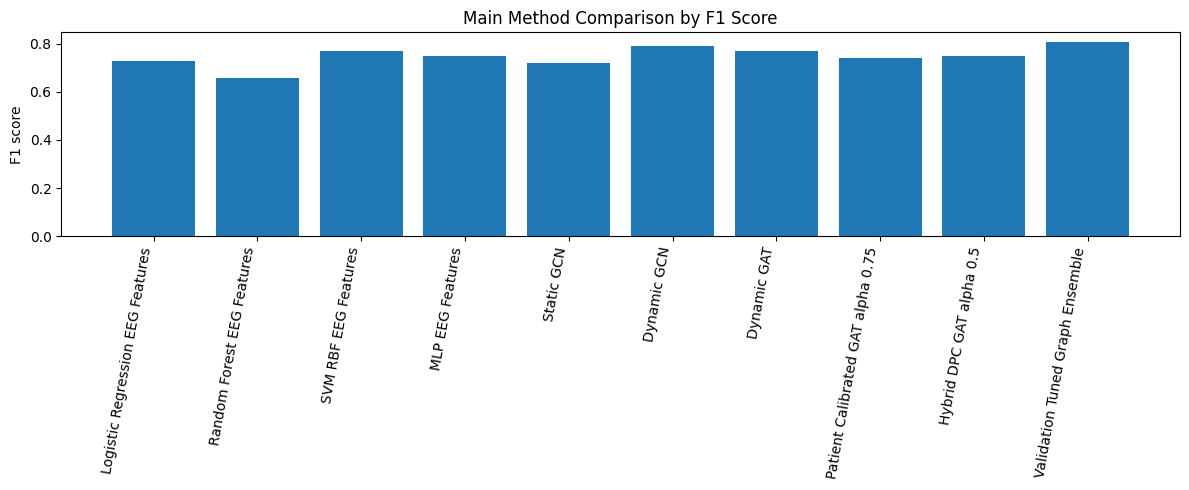

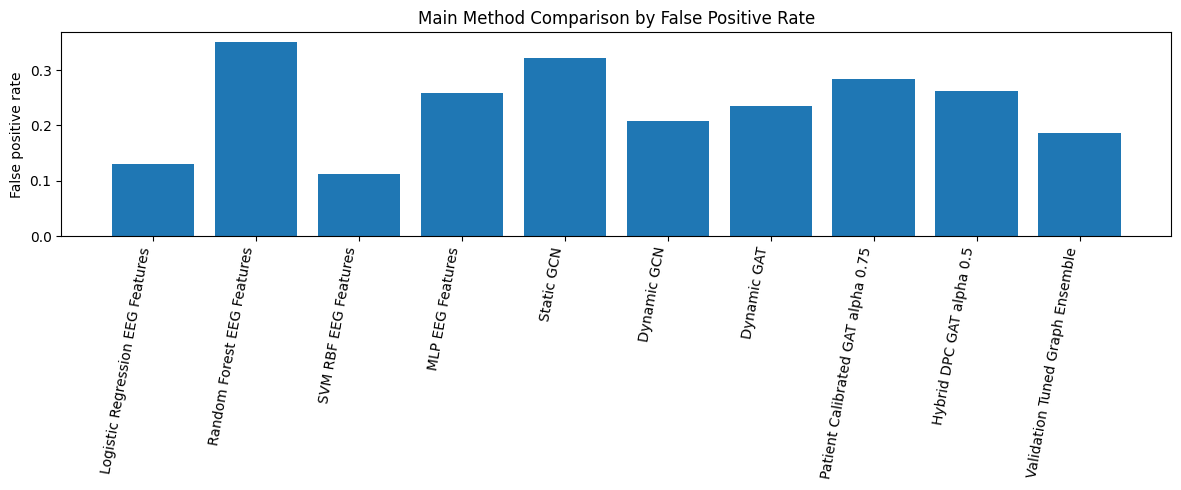

Report comparison plots saved:
/content/Final_EEG_Graph_Seizure_Project/results/main_method_comparison_f1.png
/content/Final_EEG_Graph_Seizure_Project/results/main_method_comparison_fpr.png


In [31]:
# I create a compact figure that compares the main methods for the report.

main_methods = [
    "Logistic Regression EEG Features",
    "Random Forest EEG Features",
    "SVM RBF EEG Features",
    "MLP EEG Features",
    "Static GCN",
    "Dynamic GCN",
    "Dynamic GAT",
    best_dpc_method,
    best_hybrid_method,
    "Validation Tuned Graph Ensemble"
]

main_methods = [m for m in main_methods if m in final_results_df.index]

compact_df = final_results_df.loc[main_methods].reset_index().rename(columns={"index": "method"})

plt.figure(figsize=(12, 5))
plt.bar(compact_df["method"], compact_df["f1"])
plt.xticks(rotation=80, ha="right")
plt.ylabel("F1 score")
plt.title("Main Method Comparison by F1 Score")
plt.tight_layout()

main_f1_path = RESULTS_DIR / "main_method_comparison_f1.png"
plt.savefig(main_f1_path, dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(compact_df["method"], compact_df["false positive rate"])
plt.xticks(rotation=80, ha="right")
plt.ylabel("False positive rate")
plt.title("Main Method Comparison by False Positive Rate")
plt.tight_layout()

main_fpr_path = RESULTS_DIR / "main_method_comparison_fpr.png"
plt.savefig(main_fpr_path, dpi=200)
plt.show()

print("Report comparison plots saved:")
print(main_f1_path)
print(main_fpr_path)

In [32]:
final_summary = {
    "project title": "Patient Calibrated Dynamic Graph Fusion for Cross Patient EEG Seizure Detection",
    "final selected method": final_model_name,
    "train patients": train_patients,
    "validation patients": val_patients,
    "test patients": test_patients,
    "total windows": int(len(y)),
    "seizure windows": int(np.sum(y == 1)),
    "non seizure windows": int(np.sum(y == 0)),
    "calibration windows": int(np.sum(calibration_mask)),
    "best patient calibrated method": best_dpc_method,
    "best hybrid method": best_hybrid_method,
    "strongest individual baseline": strongest_individual,
    "final results file": str(final_results_path),
    "ablation file": str(ablation_path),
    "patient results file": str(patient_results_path),
    "bootstrap summary file": str(bootstrap_summary_path),
    "robustness summary file": str(robustness_summary_path)
}

summary_path = RESULTS_DIR / "final_project_summary.json"

with open(summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("Final summary saved to:", summary_path)
display(pd.DataFrame([final_summary]))

Final summary saved to: /content/Final_EEG_Graph_Seizure_Project/results/final_project_summary.json


,project title,final selected method,train patients,validation patients,test patients,total windows,seizure windows,non seizure windows,calibration windows,best patient calibrated method,best hybrid method,strongest individual baseline,final results file,ablation file,patient results file,bootstrap summary file,robustness summary file
0,Patient Calibrated Dynamic Graph Fusion for Cr...,Validation Tuned Graph Ensemble,"[chb05, chb06, chb08, chb10]",[chb03],"[chb07, chb01, chb02]",2712,678,2034,160,Patient Calibrated GAT alpha 0.75,Hybrid DPC GAT alpha 0.5,Dynamic GCN,/content/Final_EEG_Graph_Seizure_Project/resul...,/content/Final_EEG_Graph_Seizure_Project/resul...,/content/Final_EEG_Graph_Seizure_Project/resul...,/content/Final_EEG_Graph_Seizure_Project/resul...,/content/Final_EEG_Graph_Seizure_Project/resul...


In [33]:
readme_text = f"""
# Patient Calibrated Dynamic Graph Fusion for Cross Patient EEG Seizure Detection

## Project overview

This project implements a deep learning pipeline for cross patient EEG seizure detection using the CHB MIT Scalp EEG dataset. Each EEG window is converted into a dynamic graph where EEG electrodes are nodes and functional connectivity between channels forms the graph edges.

The main contribution is a patient calibrated dynamic graph fusion framework. The system builds patient normal baseline graphs from non seizure calibration windows, creates patient calibrated graph representations, trains graph based seizure detectors, and then combines the strongest dynamic graph model with patient calibrated graph attention models using validation tuned ensemble fusion.

## Main contribution

The proposed method does not use CNN based image classification or transfer learning. Instead, it uses EEG signal features, dynamic graph construction, patient baseline graph calibration, graph neural networks, graph attention, validation tuned thresholding, ensemble fusion, bootstrap testing, and repeated patient split testing.

The key idea is to use patient specific normal EEG connectivity to help reduce false alarms while preserving seizure sensitivity.

## Dataset

Dataset: CHB MIT Scalp EEG Database
Source used by the notebook: https://physionet.org/files/chbmit/1.0.0

The notebook automatically downloads a controlled subset of seizure containing EDF files from selected patients.

Selected patients:
{", ".join(PATIENT_IDS)}

The notebook uses:
{MAX_SEIZURE_FILES_PER_PATIENT} seizure EDF files per patient.

## Files in the code package

Recommended files to submit:

1. Final Colab notebook
2. README.md
3. results folder created by the notebook
4. final report PDF
5. LaTeX project folder
6. presentation poster

The results folder contains:
1. final_model_comparison.csv
2. main_ablation_table.csv
3. patient_wise_final_results.csv
4. bootstrap_summary.csv
5. repeated_patient_split_summary.csv
6. confusion_matrix_final_model.png
7. roc_curve_final_model.png
8. main_method_comparison_f1.png
9. main_method_comparison_fpr.png
10. final_project_summary.json

## How to run

1. Open the notebook in Google Colab.
2. Select Runtime.
3. Select Run all.
4. The notebook will install packages, download the selected EEG files, process the data, train all models, run evaluations, and save the outputs.

Google Drive is disabled by default so the professor can run the notebook without a permission prompt.

To save outputs permanently to Google Drive, change this line in the configuration cell:

USE_GOOGLE_DRIVE = True

## Required libraries

The notebook installs the required libraries automatically.

Main libraries:
1. Python 3
2. NumPy
3. Pandas
4. SciPy
5. MNE
6. scikit learn
7. PyTorch
8. Matplotlib
9. tqdm

## Methodology summary

The pipeline follows these stages:

1. Download selected CHB MIT EDF files.
2. Parse seizure start and end annotations from the summary files.
3. Select common bipolar EEG channels.
4. Resample the EEG to 128 Hz.
5. Apply bandpass filtering from 0.5 to 45 Hz.
6. Segment EEG into 4 second windows with 2 second stride.
7. Label each window as seizure or non seizure.
8. Extract time and frequency features from each EEG channel.
9. Build dynamic graph adjacency matrices using channel correlation.
10. Build patient normal baseline graphs using reserved non seizure calibration windows.
11. Create patient calibrated adjacency matrices.
12. Train traditional machine learning baselines.
13. Train MLP baseline.
14. Train Static GCN, Dynamic GCN, and Dynamic GAT.
15. Train Patient Calibrated GAT and Hybrid DPC GAT models.
16. Search validation tuned graph ensemble weights.
17. Evaluate final performance on unseen test patients.
18. Run bootstrap testing against the strongest individual baseline.
19. Run repeated patient split robustness testing.
20. Save tables, figures, and summaries.

## Baselines

The notebook compares the proposed method with:

1. Logistic Regression
2. Random Forest
3. SVM RBF
4. MLP on EEG features
5. Static GCN
6. Dynamic GCN
7. Dynamic GAT
8. Patient Calibrated GAT
9. Hybrid DPC GAT
10. Validation Tuned Graph Ensemble

## Evaluation metrics

The notebook reports:

1. Accuracy
2. Precision
3. Recall sensitivity
4. Specificity
5. F1 score
6. ROC AUC
7. False positive rate
8. False negative rate
9. Confusion matrix
10. Patient wise results
11. Bootstrap confidence intervals
12. Repeated patient split robustness

## Expected runtime

Runtime depends on Colab resources. The first run is slower because EDF files are downloaded and processed. After that, cached processed files are reused unless FORCE_REPROCESS is set to True.

## Important notes

The final notebook is designed for honest evaluation. It uses patient level splitting instead of random window splitting to reduce data leakage. Validation and test patients have separate reserved calibration windows that are not used for scoring.

The project should not claim that graph based EEG seizure detection is completely new. The correct claim is that this project proposes and evaluates a patient calibrated dynamic graph fusion framework and compares it against multiple baselines.

## Author

ESMAIL IBRAHIM MOHAMMED AL NAKEEB
ID: 2598555
"""

readme_path = PROJECT_DIR / "README.md"

with open(readme_path, "w") as f:
    f.write(readme_text.strip())

print("README created at:", readme_path)
print(readme_text[:1200])

README created at: /content/Final_EEG_Graph_Seizure_Project/README.md

# Patient Calibrated Dynamic Graph Fusion for Cross Patient EEG Seizure Detection

## Project overview

This project implements a deep learning pipeline for cross patient EEG seizure detection using the CHB MIT Scalp EEG dataset. Each EEG window is converted into a dynamic graph where EEG electrodes are nodes and functional connectivity between channels forms the graph edges.

The main contribution is a patient calibrated dynamic graph fusion framework. The system builds patient normal baseline graphs from non seizure calibration windows, creates patient calibrated graph representations, trains graph based seizure detectors, and then combines the strongest dynamic graph model with patient calibrated graph attention models using validation tuned ensemble fusion.

## Main contribution

The proposed method does not use CNN based image classification or transfer learning. Instead, it uses EEG signal features, dynamic gr

In [34]:
import shutil

zip_base = PROJECT_DIR / "final_eeg_project_outputs"

if zip_base.with_suffix(".zip").exists():
    zip_base.with_suffix(".zip").unlink()

shutil.make_archive(str(zip_base), "zip", root_dir=PROJECT_DIR)

print("Final output zip created:")
print(str(zip_base.with_suffix(".zip")))
print("Download this zip if you want to keep all generated results and README.")

Final output zip created:
/content/Final_EEG_Graph_Seizure_Project/final_eeg_project_outputs.zip
Download this zip if you want to keep all generated results and README.


In [35]:
print("Final interpretation")
print()
print("Project title:")
print("Patient Calibrated Dynamic Graph Fusion for Cross Patient EEG Seizure Detection")
print()
print("What the project does:")
print("It converts EEG windows into dynamic brain connectivity graphs and uses graph neural networks to detect seizure activity in unseen patients.")
print()
print("Main contribution:")
print("The contribution is a patient calibrated dynamic graph fusion method that combines standard dynamic graph learning with patient specific graph calibration and validation tuned ensemble selection.")
print()
print("Final selected method:")
print(final_model_name)
print()
print("Best final test results:")
display(final_results_df.head(5))
print()
print("Main ablation:")
display(ablation_df)
print()
print("Repeated split robustness summary:")
display(robustness_summary_df)
print()
print("All output files are saved in:")
print(RESULTS_DIR)

Final interpretation

Project title:
Patient Calibrated Dynamic Graph Fusion for Cross Patient EEG Seizure Detection

What the project does:
It converts EEG windows into dynamic brain connectivity graphs and uses graph neural networks to detect seizure activity in unseen patients.

Main contribution:
The contribution is a patient calibrated dynamic graph fusion method that combines standard dynamic graph learning with patient specific graph calibration and validation tuned ensemble selection.

Final selected method:
Validation Tuned Graph Ensemble

Best final test results:


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate,false negative rate,tn,fp,fn,tp
Validation Tuned Graph Ensemble,0.862772,0.684039,0.981308,0.814176,0.806142,0.983582,0.185824,0.018692,425.0,97.0,4.0,210.0
Dynamic GCN,0.847826,0.659375,0.985981,0.791188,0.790262,0.981810,0.208812,0.014019,413.0,109.0,3.0,211.0
SVM RBF EEG Features,0.861413,0.743478,0.799065,0.886973,0.770270,0.904268,0.113027,0.200935,463.0,59.0,43.0,171.0
Dynamic GAT,0.828804,0.631737,0.985981,0.764368,0.770073,0.985265,0.235632,0.014019,399.0,123.0,3.0,211.0
MLP EEG Features,0.809783,0.607558,0.976636,0.741379,0.749104,0.973816,0.258621,0.023364,387.0,135.0,5.0,209.0



Main ablation:


,accuracy,precision,recall sensitivity,specificity,f1,roc auc,false positive rate
Logistic Regression EEG Features,0.835598,0.703057,0.752336,0.869732,0.726862,0.875756,0.130268
Random Forest EEG Features,0.724185,0.514589,0.906542,0.649425,0.656514,0.928376,0.350575
SVM RBF EEG Features,0.861413,0.743478,0.799065,0.886973,0.770270,0.904268,0.113027
MLP EEG Features,0.809783,0.607558,0.976636,0.741379,0.749104,0.973816,0.258621
Static GCN,0.771739,0.560209,1.000000,0.678161,0.718121,0.981622,0.321839
Dynamic GCN,0.847826,0.659375,0.985981,0.791188,0.790262,0.981810,0.208812
Dynamic GAT,0.828804,0.631737,0.985981,0.764368,0.770073,0.985265,0.235632
Patient Calibrated GAT alpha 0.75,0.797554,0.590028,0.995327,0.716475,0.740870,0.983009,0.283525
Hybrid DPC GAT alpha 0.5,0.808424,0.605187,0.981308,0.737548,0.748663,0.970933,0.262452
Validation Tuned Graph Ensemble,0.862772,0.684039,0.981308,0.814176,0.806142,0.983582,0.185824



Repeated split robustness summary:


,method,number of splits,accuracy mean,accuracy std,precision mean,precision std,recall sensitivity mean,recall sensitivity std,specificity mean,specificity std,f1 mean,f1 std,roc auc mean,roc auc std,false positive rate mean,false positive rate std,false negative rate mean,false negative rate std
0,Dynamic GCN,3,0.791092,0.077763,0.621946,0.100674,0.687355,0.266688,0.834659,0.034720,0.645241,0.163655,0.881411,0.085683,0.165341,0.034720,0.312645,0.266688
2,Validation Tuned Fusion,3,0.775365,0.038674,0.617241,0.086944,0.695014,0.264756,0.809069,0.099405,0.631056,0.100679,0.888411,0.078534,0.190931,0.099405,0.304986,0.264756
1,Hybrid DPC GAT alpha 0.5,3,0.769744,0.034821,0.598875,0.061485,0.699961,0.253923,0.799072,0.088132,0.628033,0.098107,0.887393,0.077553,0.200928,0.088132,0.300039,0.253923



All output files are saved in:
/content/Final_EEG_Graph_Seizure_Project/results
